# Multi-Modal Genomic Transformer Model

This notebook implements a Transformer-based model designed for multi-task learning on genomic data. The model simultaneously predicts masked DNA nucleotides (a self-supervised task similar to Masked Language Modeling) and masked RNA expression states (a regression/classification task). This approach aims to leverage the interdependencies between DNA sequence and gene expression.

##0. Random Seed
In order to make the results as reproducible as possible, we introduce a random seed.

In [ ]:
import random
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
print(f"Random seeds set to {SEED} for reproducibility.")

Random seeds set to 42 for reproducibility.


## 1. Imports and Global Constants

This section imports all necessary Python libraries and defines global constants used throughout the model. These constants include hyperparameters for the Transformer architecture, training parameters, and crucial values for the custom masking strategies.

In [ ]:
!pip install logomaker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.2/13.2 MB 51.5 MB/s eta 0:00:00


In [ ]:
import math
import copy
import random
import os
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split, Dataset, Subset
import torch.optim as optim
import torch.cuda.amp as amp
from torch.cuda.amp import autocast, GradScaler
import torch.nn.functional as F

import matplotlib.pyplot as plt
import logomaker
import seaborn as sns
from collections import Counter
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# Original number of nucleotide types (A, C, G, T, N)
NUM_NUCLEOTIDES_ORIGINAL = 5

# Index used for the MASK token in the one-hot encoded DNA input.
MASK_NUCLEOTIDE_INDEX = NUM_NUCLEOTIDES_ORIGINAL

# One-hot dimension including original nucleotides + MASK token
ONE_HOT_NUCLEOTIDE_DIM = NUM_NUCLEOTIDES_ORIGINAL + 1 # Total one-hot dimension (A,C,G,T,N,MASK = 6)

# Special value for masked RNA expression in the input (distinct from 0.0 or 1.0)
MASK_EXPRESSION_VALUE = 0.5

# Masking probabilities
DNA_MASK_PROBABILITY = 0.15
RNA_MASK_FRACTION = 0.5

# BERT-like masking strategy probabilities for DNA
BERT_MASK_REPLACEMENT_PROB = 0.8  # 80% of the time: replace with MASK_TOKEN
BERT_RANDOM_REPLACEMENT_PROB = 0.1 # 10% of the time: replace with random original nucleotide
BERT_ORIGINAL_REPLACEMENT_PROB = 0.1 # 10% of the time: keep original nucleotide

# train, val, test split
TRAIN_CHROM_RATIO = 0.8
VAL_CHROM_RATIO = 0.1
TEST_CHROM_RATIO = 0.1

# Total input features per position: ONE_HOT_NUCLEOTIDE_DIM (6) + 1 (for Expression) = 7
NEW_INPUT_FEATURES = ONE_HOT_NUCLEOTIDE_DIM + 1

# Model Hyperparameters
D_MODEL = 128       # Increased from 128 (more embedding dimensions)
NUM_HEADS = 4       # Increased from 4 (more attention heads)
NUM_LAYERS = 4      # Increased from 3 (deeper Transformer)
D_FF = 256         # Increased from 256 (larger feed-forward network)
DROPOUT = 0.1       # Keep or adjust as needed


# Dataset Parameters
DATA_SUBSET_RATIO = None # Set to a float (e.g., 0.1) for a subset; Set to None for full dataset
DATA_SUBSET_SIZE = 100000 # Set to an integer (e.g., 200000) for a subset; Set to None for full dataset
USE_CHROMOSOME_SPLIT = True # Use chromosome-based split if True, else random split

if DATA_SUBSET_RATIO is not None and (DATA_SUBSET_RATIO <= 0 or DATA_SUBSET_RATIO >= 1):
    raise ValueError("DATA_SUBSET_RATIO must be a float between 0 and 1 (exclusive). Use None for full dataset.")
if DATA_SUBSET_SIZE is not None and (DATA_SUBSET_SIZE <= 0 or not isinstance(DATA_SUBSET_SIZE, int)):
    raise ValueError("DATA_SUBSET_SIZE must be a positive integer. Use None for full dataset.")
if DATA_SUBSET_RATIO is not None and DATA_SUBSET_SIZE is not None:
    raise ValueError("Please set either DATA_SUBSET_RATIO or DATA_SUBSET_SIZE, not both. Use None for full dataset.")

# Training Hyperparameters
BATCH_SIZE = 8
LEARNING_RATE = 0.0001
NUM_EPOCHS = 15
GRADIENT_ACCUMULATION_STEPS = 8
WARMUP_STEPS = 100 # For learning rate scheduler

NUM_WORKERS = 2 # Number of data loading workers

# Placeholder for dynamically detected sequence length (window_size from data)
SEQ_LENGTH = None
# Mapping from integer to nucleotide character for plotting
NUCLEOTIDE_MAP_INT_TO_CHAR = {0: 'A', 1: 'C', 2: 'G', 3: 'T', 4: 'N'}
NUCLEOTIDE_CHARS = ['A', 'C', 'G', 'T', 'N'] # Ordered for logomaker columns

## 2. Utility Functions

This section includes helper functions that are not part of the core model but are essential for the overall pipeline, such as determining the correct data directory based on the execution environment.

In [ ]:
# --- UTILITY FUNCTIONS ---

def get_data_dir():
    """
    Determines the correct data directory based on the execution environment.
    This function makes the code portable between Colab, local PyCharm, and cluster.
    """
    # Default to current working directory for local/cluster
    data_directory = os.path.join(os.getcwd(), 'data/')

    # Attempt to detect Google Colab and use Google Drive path
    try:
        from google.colab import drive
        drive.mount('/content/gdrive')
        # This path assumes your 'DnARnAProject' folder is directly in 'My Drive', and contains the data
        google_drive_project_path = '/content/gdrive/MyDrive/DnARnAProject/'
        data_directory = os.path.join(google_drive_project_path, 'data/')
        print("Detected Google Colab environment. Using Google Drive path.")
    except ImportError:
        print("Not in Google Colab. Using local/cluster path.")

    if not os.path.isdir(data_directory):
        print(f"Error: The data directory '{data_directory}' does not exist.")
        print("Please ensure your data is located correctly (e.g., in a 'data/' folder relative to your script, or in Google Drive).")
        exit() # Exit if data directory is not found
    return data_directory

## 3. Transformer Core Modules

This section defines the fundamental building blocks of the Transformer architecture:
- **`MultiHeadAttention`**: Implements the core attention mechanism, allowing the model to weigh the importance of different parts of the input sequence.
- **`PositionWiseFeedForward`**: A simple two-layer feed-forward network applied independently to each position.
- **`PositionalEncoding`**: Adds information about the position of tokens in the sequence, as Transformers are permutation-invariant.

In [ ]:
# --- MODEL MODULES ---

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        attn_scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        if mask is not None:
            # Fill masked positions with a very small number for softmax
            attn_scores = attn_scores.masked_fill(mask == 0, -1e9)
        attn_probs = torch.softmax(attn_scores, dim=-1)
        output = torch.matmul(attn_probs, V)
        return output, attn_probs

    def split_heads(self, x):
        batch_size, seq_length, d_model = x.size()
        return x.view(batch_size, seq_length, self.num_heads, self.d_k).transpose(1, 2)

    def combine_heads(self, x):
        batch_size, _, seq_length, d_k = x.size()
        return x.transpose(1, 2).contiguous().view(batch_size, seq_length, self.d_model)

    def forward(self, Q, K, V, mask=None):
        Q = self.split_heads(self.W_q(Q))
        K = self.split_heads(self.W_k(K))
        V = self.split_heads(self.W_v(V))

        attn_output, attn_probs = self.scaled_dot_product_attention(Q, K, V, mask)

        output = self.W_o(self.combine_heads(attn_output))
        return output, attn_probs


class PositionWiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff):
        super(PositionWiseFeedForward, self).__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_seq_length):
        super(PositionalEncoding, self).__init__()

        pe = torch.zeros(max_seq_length, d_model)
        position = torch.arange(0, max_seq_length, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * -(math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

## 4. Transformer Encoder Layer and Main Model

This section defines the full encoder layer of the Transformer and the main `DNASequenceClassifier` model. The `DNASequenceClassifier` is equipped with two distinct prediction heads for multi-task learning:
- One head for reconstructing masked DNA nucleotides.
- Another head for predicting masked RNA expression states.

In [ ]:

class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(EncoderLayer, self).__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.feed_forward = PositionWiseFeedForward(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask):
        attn_output, attn_probs = self.self_attn(x, x, x, mask)
        x = self.norm1(x + self.dropout(attn_output)) # Add & Norm for attention
        ff_output = self.feed_forward(x)
        x = self.norm2(x + self.dropout(ff_output)) # Add & Norm for feed-forward
        return x, attn_probs


# The DNARNASequenceClassifier (a modified Transformer Encoder) for DNA nucleotide reconstruction and masked expression prediction

class DNARNASequenceClassifier(nn.Module):
    def __init__(self, input_features, d_model, num_heads, num_layers, d_ff, max_seq_length, dropout, num_nucleotides_original):
        """
        Initializes the DNARNASequenceClassifier for a masked expression prediction task.

        Args:
            input_features (int): Number of input features per position (e.g., 5 for one-hot A,C,G,T,N + 1 for expression state).
            d_model (int): Dimension of the model's embeddings.
            num_heads (int): Number of attention heads.
            num_layers (int): Number of encoder layers.
            d_ff (int): Dimension of the feed-forward network.
            max_seq_length (int): Maximum sequence length for positional encoding.
            dropout (float): Dropout rate.
        """
        super(DNARNASequenceClassifier, self).__init__()

        # Input projection from (input_features) to d_model dimension
        # input_features will now be NUM_NUCLEOTIDES (5) + 1 (for expression state) = 6
        self.input_projection = nn.Linear(input_features, d_model)
        self.positional_encoding = PositionalEncoding(d_model, max_seq_length)
        self.dropout = nn.Dropout(dropout)
        self.d_model = d_model # Ensure d_model is saved as an attribute

        self.encoder_layers = nn.ModuleList(
            [EncoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)])
        self.dna_prediction_head = nn.Linear(d_model, num_nucleotides_original)
        self.dna_prediction_head = nn.Linear(d_model, 5) # Assuming 5 original nucleotides (A,C,G,T,N)

        # Prediction head for per-position binary output (expressed/not expressed)
        # This will operate on the encoder's output for each position.
        self.prediction_head = nn.Linear(d_model, 1) # Outputs a single logit per position


    def forward(self, src):
        """
        Forward pass for the DNA Sequence Classifier in masked expression mode.

        Args:
            src (torch.Tensor): Input sequence tensor.
                                Expected shape: (batch_size, sequence_length, input_features)
                                (e.g., batch_size, window_size, NUM_NUCLEOTIDES + 1)
        Returns:
            tuple: (
                torch.Tensor: Logits for DNA nucleotide prediction (batch_size, seq_length, NUM_NUCLEOTIDES_ORIGINAL),
                torch.Tensor: Logits for RNA expression prediction (batch_size, seq_length, 1),
                list: List of attention probabilities from each encoder layer (each element: batch_size, num_heads, seq_length, seq_length)
            )
        """
        src_mask = None # Assuming no explicit padding mask needed if window_size is fixed

        # Project input features to d_model and add positional encoding
        # Apply scaling by sqrt(d_model) before positional encoding
        src_embedded = self.input_projection(src) * math.sqrt(self.d_model)
        src_embedded = self.dropout(self.positional_encoding(src_embedded))

        enc_output = src_embedded
        # Store attention probabilities if we want to analyze them later
        all_attention_weights = [] # Renamed from all_attn_probs for consistency with return
        for enc_layer in self.encoder_layers:
            enc_output, attn_probs = enc_layer(enc_output, src_mask)
            all_attention_weights.append(attn_probs)

        # --- Per-position prediction for both tasks ---
        dna_logits = self.dna_prediction_head(enc_output)
        expression_logits = self.prediction_head(enc_output)

        return dna_logits, expression_logits, all_attention_weights

## 5. Data Loading - Base Dataset (`GenomeExpressionDataset`)

This custom PyTorch `Dataset` handles the initial loading and preprocessing of genomic data. It reads DNA sequences and corresponding RNA expression labels from `.npz` and `.parquet` files. Key features include:
- Loading integer-encoded DNA sequences and float32 expression values.
- Applying reverse complement transformation for sequences on the '-' strand.
- Providing chromosome information, which is crucial for a robust train/validation/test split.

In [ ]:
# --- DATASET CLASSES ---

class GenomeExpressionDataset(Dataset):
    """
    Custom Dataset for loading DNA sequence and expression data for genomic regions.
    Loads data from pre-processed .npz and .parquet files.
    Handles reverse complement for '-' strand sequences.
    Returns integer-encoded DNA sequences and float32 expression labels.
    Provides chromosome information for splitting.
    """
    def __init__(self, data_dir):
        self.data_dir = data_dir

        self.data_npz_path = os.path.join(data_dir, 'data.npz')
        self.regions_parquet_path = os.path.join(data_dir, 'regions.parquet')

        try:
            loaded_npz = np.load(self.data_npz_path, allow_pickle=True)
            self.sequence_data = loaded_npz['sequence'] # Stored as integers (0-4)
            self.expression_plus_data = loaded_npz['expressed_plus']
            self.expression_minus_data = loaded_npz['expressed_minus']
            loaded_npz.close()
        except KeyError as e:
            available_keys = list(np.load(self.data_npz_path).keys()) if os.path.exists(self.data_npz_path) else "File not found during key check."
            raise RuntimeError(f"KeyError: Key '{e}' not found in {self.data_npz_path}. "
                               f"Available keys: {available_keys}. "
                               f"Please check your .npz file structure.")
        except Exception as e:
            raise RuntimeError(f"Could not load data from {self.data_npz_path}. Make sure the file exists and is not corrupted: {e}")

        try:
            self.regions_df = pd.read_parquet(self.regions_parquet_path)
            # Ensure 'contig' column exists, as 'chromosome' was not found in previous run
            if 'contig' not in self.regions_df.columns:
                raise ValueError(f"The 'regions.parquet' file must contain a 'contig' column for splitting. 'chromosome' column was not found.")
        except Exception as e:
            raise RuntimeError(f"Could not load regions from {self.regions_parquet_path}. Make sure the file exists and is not corrupted: {e}")

        assert len(self.sequence_data) == len(self.expression_plus_data) == len(self.expression_minus_data)

        # Map for reverse complement: A<->T, C<->G, N<->N (0<->3, 1<->2, 4<->4)
        self.complement_map = np.array([3, 2, 1, 0, 4], dtype=np.uint8)

    def __len__(self):
        return len(self.regions_df)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.tolist()

        region_info = self.regions_df.iloc[idx]

        offset = region_info['offset']
        window_size = region_info['window_size']
        strand = region_info['strand']

        # Get original sequence (integer encoded) and expression labels
        original_nucleotide_segment = self.sequence_data[offset : offset + window_size][::-1].copy()

        if strand == '+':
            original_expression_label_segment = self.expression_plus_data[offset : offset + window_size].copy()
        else: # strand == '-'
            # Apply reverse complement to DNA sequence
            original_nucleotide_segment = self.complement_map[original_nucleotide_segment][::-1].copy()
            # Corresponding expression label segment for the minus strand (already handled by preprocessing)
            original_expression_label_segment = self.expression_minus_data[offset : offset + window_size][::1].copy()

        # Ensure expression_label_segment is a float32 tensor
        original_expression_labels = torch.tensor(original_expression_label_segment, dtype=torch.float32)

        # Return original integer sequence and expression labels
        return torch.tensor(original_nucleotide_segment, dtype=torch.long), original_expression_labels

    def get_all_sample_chromosomes(self):
        """Returns a list of chromosome identifiers for all samples."""
        return self.regions_df['contig'].tolist()

## 6. Data Loading - Masking Dataset (`MultiModalMaskingDataset`)

This is a crucial component that wraps the `GenomeExpressionDataset` to apply the specific masking strategies required for multi-task learning:
- **RNA Masking**: A *contiguous 50%* span of RNA expression values is masked with a special value (`MASK_EXPRESSION_VALUE`).
- **DNA Masking**: *Random 15%* of DNA nucleotides are masked using a BERT-like strategy (80% `[MASK]` token, 10% random nucleotide, 10% original nucleotide).

This dataset prepares the input for the model (`model_input`) and provides the corresponding ground truth labels (`original_nucleotide_labels`, `original_expression_labels`) and target masks (`dna_target_mask`, `rna_target_mask`) indicating which positions need to be predicted.

In [ ]:
class MultiModalMaskingDataset(Dataset):
    """
    Wraps GenomeExpressionDataset to apply both contiguous RNA masking (50%)
    and random DNA masking (15%) for a multi-task prediction.
    """
    def __init__(self, base_dataset: GenomeExpressionDataset, seq_length: int,
                 dna_mask_probability=DNA_MASK_PROBABILITY, rna_mask_fraction=RNA_MASK_FRACTION):
        self.base_dataset = base_dataset
        self.seq_length = seq_length # Fixed sequence length from global constant
        self.dna_mask_probability = DNA_MASK_PROBABILITY
        self.rna_mask_fraction = rna_mask_fraction

        self.num_nucleotides_original = NUM_NUCLEOTIDES_ORIGINAL
        self.one_hot_nucleotide_dim = ONE_HOT_NUCLEOTIDE_DIM
        self.mask_nucleotide_index = MASK_NUCLEOTIDE_INDEX
        self.mask_expression_value = MASK_EXPRESSION_VALUE

        self.bert_mask_replacement_prob = BERT_MASK_REPLACEMENT_PROB
        self.bert_random_replacement_prob = BERT_RANDOM_REPLACEMENT_PROB
        self.bert_original_replacement_prob = BERT_ORIGINAL_REPLACEMENT_PROB

    def __len__(self):
        return len(self.base_dataset)

    def _one_hot_encode_dna(self, sequence_segment_int, one_hot_dim):
        """
        Helper to one-hot encode nucleotide integer indices for model input.
        Handles the expanded dimension for the MASK token.
        """
        one_hot_tensor = torch.zeros(len(sequence_segment_int), one_hot_dim, dtype=torch.float32)
        # Scatter original nucleotide values (0-4)
        one_hot_tensor.scatter_(1, sequence_segment_int.unsqueeze(1).long(), 1)
        return one_hot_tensor

    def __getitem__(self, idx):
        # Retrieve original integer-encoded DNA sequence and float32 expression labels
        # original_nucleotide_labels: (seq_len,) -> integer indices 0-4
        # original_expression_labels: (seq_len,) -> float32 values 0.0 or 1.0
        original_nucleotide_labels, original_expression_labels = self.base_dataset[idx]

        # Initialize tensors for model input and target masks
        # For model_input, we need to convert original_nucleotide_labels to one-hot
        input_nucleotide_features = self._one_hot_encode_dna(original_nucleotide_labels, self.one_hot_nucleotide_dim) # (seq_len, 6)

        # Input expression state will be (seq_len, 1)
        input_expression_states = original_expression_labels.clone().unsqueeze(-1) # (seq_len, 1)

        # Initialize masks for what we actually need to predict
        dna_target_mask = torch.full((self.seq_length,), False, dtype=torch.bool)
        rna_target_mask = torch.full((self.seq_length,), False, dtype=torch.bool)

        # --- Apply RNA Masking (Contiguous 50%) ---
        rna_mask_span_length = max(1, int(self.seq_length * self.rna_mask_fraction))
        if self.seq_length > rna_mask_span_length:
            rna_mask_start_idx = random.randint(0, self.seq_length - rna_mask_span_length)
        else: # Mask the entire sequence if span length is >= sequence length
            rna_mask_start_idx = 0
            rna_mask_span_length = self.seq_length
        rna_mask_end_idx = rna_mask_start_idx + rna_mask_span_length

        input_expression_states[rna_mask_start_idx : rna_mask_end_idx] = self.mask_expression_value
        rna_target_mask[rna_mask_start_idx : rna_mask_end_idx] = True

        # --- Apply DNA Masking (Random 15% with BERT-like strategy) ---
        for i in range(self.seq_length):
            if random.random() < self.dna_mask_probability:
                dna_target_mask[i] = True # Mark this position for DNA prediction

                rand_val = random.random()
                if rand_val < self.bert_mask_replacement_prob:
                    # 80% of the time: replace with MASK_NUCLEOTIDE_INDEX
                    input_nucleotide_features[i] = torch.zeros(self.one_hot_nucleotide_dim)
                    input_nucleotide_features[i, self.mask_nucleotide_index] = 1.0
                elif rand_val < (self.bert_mask_replacement_prob + self.bert_random_replacement_prob):
                    # 10% of the time: replace with a random original nucleotide (0-4)
                    random_nuc_idx = random.randint(0, self.num_nucleotides_original - 1)
                    input_nucleotide_features[i] = torch.zeros(self.one_hot_nucleotide_dim)
                    input_nucleotide_features[i, random_nuc_idx] = 1.0
                # else (10% of the time): keep original nucleotide (no change to input_nucleotide_features[i] needed)

        # Concatenate nucleotide features with expression states to form model input
        # Resulting shape: (seq_length, ONE_HOT_NUCLEOTIDE_DIM + 1)
        model_input = torch.cat((input_nucleotide_features, input_expression_states), dim=-1)

        # Return:
        # model_input: (seq_len, ONE_HOT_NUCLEOTIDE_DIM + 1) with masked values for model input
        # original_nucleotide_labels: (seq_len,) -> true integer labels (0-4) for DNA prediction target
        # original_expression_labels: (seq_len,) -> true float labels (0.0/1.0) for RNA prediction target
        # dna_target_mask: (seq_len,) -> boolean, True where DNA was masked and needs prediction
        # rna_target_mask: (seq_len,) -> boolean, True where RNA was masked and needs prediction
        return model_input, original_nucleotide_labels, original_expression_labels, dna_target_mask, rna_target_mask

## 7. Data Loading and Chromosome-Based Splitting Logic

This section orchestrates the data loading and prepares the datasets for training, validation, and testing. It dynamically determines the sequence length from the loaded data and implements a robust chromosome-based splitting strategy to ensure that training, validation, and test sets contain data from entirely separate chromosomes. This prevents data leakage and provides a more realistic evaluation of the model's generalization capabilities.

A `DEBUG_DATASET_SIZE` option is included to allow for faster testing with a smaller subset of the data.

In [ ]:
# --- DATA LOADING AND SPLITTING LOGIC ---


# Device Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


# Get data directory
data_dir = get_data_dir()


# Initialize base dataset
try:
    base_full_dataset = GenomeExpressionDataset(data_dir)
    print(f"Full base dataset loaded successfully. Total samples: {len(base_full_dataset)}")


    if len(base_full_dataset) > 0:
        # Dynamically determine SEQ_LENGTH (window_size) from the first sample
        sample_dna_int, _ = base_full_dataset[0]
        SEQ_LENGTH = sample_dna_int.shape[0] # Update global variable
        print(f"Detected sequence length (window_size): {SEQ_LENGTH}")
    else:
        print("Warning: Base dataset is empty. Cannot determine SEQ_LENGTH dynamically. Please ensure data is present.")
        exit() # Exit if dataset is empty to prevent errors


except (FileNotFoundError, RuntimeError, ValueError) as e:
    print(f"Error loading base dataset: {e}")
    print("Please ensure your data files ('data.npz', 'regions.parquet') are correctly placed and formatted.")
    exit() # Exit execution if essential files/data are missing or malformed




# --- Determine the working pool of indices based SOLELY on DATA_SUBSET_SIZE ---
initial_pool_indices = list(range(len(base_full_dataset)))
full_dataset_actual_size = len(initial_pool_indices)


if DATA_SUBSET_SIZE is not None:
    if DATA_SUBSET_SIZE < full_dataset_actual_size:
        current_pool_size = max(1, DATA_SUBSET_SIZE) # Ensure at least 1 sample if data exists
        print(f"SUBSET MODE: Creating a random subset of size {current_pool_size} from the full dataset.")
        random.shuffle(initial_pool_indices) # Shuffle the full range of indices
        dataset_to_split_indices = initial_pool_indices[:current_pool_size] # Take the subset
        print(f"Working with a subset of {len(dataset_to_split_indices)} samples for splitting.")
    else: # DATA_SUBSET_SIZE is greater than or equal to the full dataset size
        print("Warning: DATA_SUBSET_SIZE is greater than or equal to the full dataset size. Using the full dataset for splitting (randomly shuffled).")
        random.shuffle(initial_pool_indices) # Shuffle the full dataset
        dataset_to_split_indices = initial_pool_indices # Use all indices, but they are shuffled
        print(f"Working with {len(dataset_to_split_indices)} samples for splitting.")
else: # DATA_SUBSET_SIZE is None
    print("No specific DATA_SUBSET_SIZE set. Using the full dataset for splitting (randomly shuffled).")
    random.shuffle(initial_pool_indices) # Shuffle the full dataset
    dataset_to_split_indices = initial_pool_indices # Use all indices, but they are shuffled
    print(f"Working with {len(dataset_to_split_indices)} samples for splitting.")


# Convert the working pool of indices to a set for efficient lookups
dataset_to_split_indices_set = set(dataset_to_split_indices)




# --- Determine Splitting Method based on USE_CHROMOSOME_SPLIT ---
if USE_CHROMOSOME_SPLIT:
    # Get all chromosome identifiers from the *entire original dataset*
    all_chromosomes_full_dataset = base_full_dataset.get_all_sample_chromosomes()


    # Filter chromosomes to only include those present in the *current pool of samples* (`dataset_to_split_indices`)
    chromosomes_in_current_pool = [all_chromosomes_full_dataset[i] for i in dataset_to_split_indices]
    unique_chromosomes = sorted(list(set(chromosomes_in_current_pool)))
    num_unique_chromosomes = len(unique_chromosomes)


    if num_unique_chromosomes < 3: # Need at least 3 chromosomes for train/val/test split
        print(f"Error: Not enough unique chromosomes in the selected pool ({len(dataset_to_split_indices)} samples) for a chromosome-based split. Found {num_unique_chromosomes}. Falling back to random split.")


        # Fallback to random split on the dataset_to_split_indices
        train_size = int(TRAIN_CHROM_RATIO * len(dataset_to_split_indices))
        val_size = int(VAL_CHROM_RATIO * len(dataset_to_split_indices))
        test_size = len(dataset_to_split_indices) - train_size - val_size


        # Adjust sizes for non-negativity and sum correctness
        if train_size < 0: train_size = 0
        if val_size < 0: val_size = 0
        if test_size < 0: test_size = 0


        total_allocated = train_size + val_size + test_size
        if total_allocated != len(dataset_to_split_indices):
            train_size += (len(dataset_to_split_indices) - total_allocated) # Add/subtract from train to balance
            if train_size < 0: train_size = 0 # Ensure no negative size after adjustment


        train_subset_indices, val_subset_indices, test_subset_indices = random_split(
            dataset_to_split_indices, [train_size, val_size, test_size])
        print(f"Performing random split: Train={len(train_subset_indices)}, Val={len(val_subset_indices)}, Test={len(test_subset_indices)}")
    else: # Enough unique chromosomes, proceed with chromosome-based splitting
        print(f"Found {num_unique_chromosomes} unique chromosomes in the selected pool: {unique_chromosomes}")


        random.shuffle(unique_chromosomes) # Shuffle chromosomes to ensure random assignment


        train_chrom_count = max(1, int(num_unique_chromosomes * TRAIN_CHROM_RATIO))
        val_chrom_count = max(1, int(num_unique_chromosomes * VAL_CHROM_RATIO))


        # Ensure at least one chromosome for test set (and others) if possible with >=3 unique chroms
        if num_unique_chromosomes - train_chrom_count - val_chrom_count < 1 and num_unique_chromosomes >= 3:
            if val_chrom_count > 1: val_chrom_count -= 1
            elif train_chrom_count > 1: train_chrom_count -= 1


        train_chroms = unique_chromosomes[:train_chrom_count]
        val_chroms = unique_chromosomes[train_chrom_count : train_chrom_count + val_chrom_count]
        test_chroms = unique_chromosomes[train_chrom_count + val_chrom_count :]


        # Handle edge cases where a set might be empty due to small number of chromosomes being shuffled
        # This logic tries to ensure each split gets at least one chromosome if possible from remaining
        if not test_chroms and val_chroms: test_chroms.append(val_chroms.pop())
        if not test_chroms and train_chroms: test_chroms.append(train_chroms.pop())
        if not val_chroms and train_chroms and len(train_chroms) > 1 and num_unique_chromosomes >= 2:
             val_chroms.append(train_chroms.pop(0))


        if num_unique_chromosomes >= 3: # Final check to populate empty sets if possible
            if not train_chroms and unique_chromosomes: train_chroms.append(unique_chromosomes.pop(0))
            if not val_chroms and unique_chromosomes: val_chroms.append(unique_chromosomes.pop(0))
            if not test_chroms and unique_chromosomes: test_chroms.append(unique_chromosomes.pop(0))




        # Filter out any potential 'None' values from complex pop() logic in edge cases
        train_chroms = [c for c in train_chroms if c is not None]
        val_chroms = [c for c in val_chroms if c is not None]
        test_chroms = [c for c in test_chroms if c is not None]




        print(f"Chromosome split: Train={train_chroms}, Val={val_chroms}, Test={test_chroms}")


        # Create index subsets based on chromosome assignments
        # 'i in dataset_to_split_indices_set' ensures we only pick from the current working pool of samples
        train_indices = [i for i, chrom in enumerate(all_chromosomes_full_dataset) if chrom in train_chroms and i in dataset_to_split_indices_set]
        val_indices = [i for i, chrom in enumerate(all_chromosomes_full_dataset) if chrom in val_chroms and i in dataset_to_split_indices_set]
        test_indices = [i for i, chrom in enumerate(all_chromosomes_full_dataset) if chrom in test_chroms and i in dataset_to_split_indices_set]


        print(f"Chromosome-based split: Train samples={len(train_indices)}, Val samples={len(val_indices)}, Test samples={len(test_indices)}")


        # Create Subsets (these are now correct indices for the base_full_dataset)
        train_subset_indices = Subset(base_full_dataset, train_indices)
        val_subset_indices = Subset(base_full_dataset, val_indices)
        test_subset_indices = Subset(base_full_dataset, test_indices)


else: # USE_CHROMOSOME_SPLIT is False
    print("Chromosome-based splitting is OFF. Performing random split on the selected samples.")
    train_size = int(TRAIN_CHROM_RATIO * len(dataset_to_split_indices))
    val_size = int(VAL_CHROM_RATIO * len(dataset_to_split_indices))
    test_size = len(dataset_to_split_indices) - train_size - val_size


    # Adjust sizes for non-negativity and sum correctness
    if train_size < 0: train_size = 0
    if val_size < 0: val_size = 0
    if test_size < 0: test_size = 0
    total_allocated = train_size + val_size + test_size
    if total_allocated != len(dataset_to_split_indices):
        train_size += (len(dataset_to_split_indices) - total_allocated)
        if train_size < 0: train_size = 0


    train_subset_indices, val_subset_indices, test_subset_indices = random_split(
        dataset_to_split_indices, [train_size, val_size, test_size])
    print(f"Performing random split: Train={len(train_subset_indices)}, Val={len(val_subset_indices)}, Test={len(test_subset_indices)}")




# Create the masking datasets using the subsets derived from either split method
train_dataset = MultiModalMaskingDataset(train_subset_indices, SEQ_LENGTH,
                                         DNA_MASK_PROBABILITY, RNA_MASK_FRACTION)
val_dataset = MultiModalMaskingDataset(val_subset_indices, SEQ_LENGTH,
                                       DNA_MASK_PROBABILITY, RNA_MASK_FRACTION)
test_dataset = MultiModalMaskingDataset(test_subset_indices, SEQ_LENGTH,
                                        DNA_MASK_PROBABILITY, RNA_MASK_FRACTION)




print(f"Final Dataset sizes: Train={len(train_dataset)}, Val={len(val_dataset)}, Test={len(test_dataset)}")


# Create DataLoaders
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)


print("DataLoaders created.")



Using device: cpu
Mounted at /content/gdrive
Detected Google Colab environment. Using Google Drive path.
Full base dataset loaded successfully. Total samples: 15705825
Detected sequence length (window_size): 2048
SUBSET MODE: Creating a random subset of size 100000 from the full dataset.
Working with a subset of 100000 samples for splitting.
Found 17 unique chromosomes in the selected pool: ['chrI', 'chrII', 'chrIII', 'chrIV', 'chrIX', 'chrM', 'chrV', 'chrVI', 'chrVII', 'chrVIII', 'chrX', 'chrXI', 'chrXII', 'chrXIII', 'chrXIV', 'chrXV', 'chrXVI']
Chromosome split: Train=['chrIX', 'chrXII', 'chrXI', 'chrX', 'chrXIII', 'chrVIII', 'chrIII', 'chrVII', 'chrXVI', 'chrV', 'chrVI', 'chrI', 'chrXIV'], Val=['chrIV'], Test=['chrXV', 'chrII', 'chrM']
Chromosome-based split: Train samples=70958, Val samples=12953, Test samples=16089
Final Dataset sizes: Train=70958, Val=12953, Test=16089
DataLoaders created.


## 8. Model Initialization, Loss Functions, and Optimizer

This section initializes the `DNARNASequenceClassifier` model with the defined hyperparameters. It also sets up the appropriate loss functions for each task and the optimizer for training. Mixed-precision training (`autocast`, `GradScaler`) is configured to improve training speed and memory efficiency on compatible hardware (e.g., NVIDIA GPUs).

In [ ]:
# --- MODEL INITIALIZATION, LOSS FUNCTIONS, OPTIMIZER ---

# Initialize model
model = DNARNASequenceClassifier(
    input_features=NEW_INPUT_FEATURES,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    d_ff=D_FF,
    max_seq_length=SEQ_LENGTH,
    dropout=DROPOUT,
    num_nucleotides_original=NUM_NUCLEOTIDES_ORIGINAL
).to(device)

print(f"Model initialized with {sum(p.numel() for p in model.parameters() if p.requires_grad):,} trainable parameters.")

# Loss functions
# For DNA (multi-class classification for nucleotides 0-4)
dna_loss_fn = nn.CrossEntropyLoss(reduction='none') # reduction='none' so we can apply mask

# For RNA (binary classification: 0 or 1)
expression_loss_fn = torch.nn.BCEWithLogitsLoss()


# Optimizer with AdamW for better regularization
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE)

# Learning rate scheduler with warmup
def lr_lambda(current_step: int):
    if current_step < WARMUP_STEPS:
        return float(current_step) / float(max(1, WARMUP_STEPS))
    return 1.0

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

# For mixed-precision training
scaler = GradScaler()

print("Model, Loss Functions, Optimizer, and Scheduler configured.")

Model initialized with 531,718 trainable parameters.
Model, Loss Functions, Optimizer, and Scheduler configured.


/tmp/ipython-input-10-3467953744.py:37: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/usr/local/lib/python3.11/dist-packages/torch/amp/grad_scaler.py:132: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  warnings.warn(


## 9. Training and Validation Functions

This section defines the `train_epoch` and `validate_epoch` functions. These functions encapsulate the core training and validation loop, including:
- Forward pass through the model.
- Calculation of DNA (masked nucleotide) and RNA (masked expression) losses.
- Application of target masks to ensure losses are calculated only for predicted positions.
- Backpropagation and optimization (including mixed-precision scaling).
- Accumulation of gradients over several batches to simulate larger batch sizes (`GRADIENT_ACCUMULATION_STEPS`).
- Calculation of accuracy metrics for both tasks.

In [ ]:

# --- TRAINING AND VALIDATION FUNCTIONS ---

def train_epoch(model, dataloader, optimizer, dna_loss_fn, expression_loss_fn, scheduler, scaler, device, accumulation_steps):
    model.train()
    total_dna_loss = 0
    total_rna_loss = 0
    total_combined_loss = 0
    correct_dna_predictions = 0
    total_dna_masked_tokens = 0
    correct_rna_predictions = 0
    total_rna_masked_tokens = 0

    optimizer.zero_grad() # Initialize gradients once per accumulation cycle

    for i, (model_input, original_dna_labels, original_rna_labels, dna_target_mask, rna_target_mask) in enumerate(dataloader):
        model_input = model_input.to(device)
        original_dna_labels = original_dna_labels.to(device) # (batch_size, seq_len)
        original_rna_labels = original_rna_labels.to(device) # (batch_size, seq_len)
        dna_target_mask = dna_target_mask.to(device) # (batch_size, seq_len)
        rna_target_mask = rna_target_mask.to(device) # (batch_size, seq_len)

        with autocast(): # For mixed-precision training
            dna_logits, expression_logits,_ = model(model_input)

            # --- DNA Loss Calculation (Masked Language Modeling) ---
            # Reshape for CrossEntropyLoss: (N, C, ...) where C is num_classes
            # target is (N, ...)
            # dna_logits: (batch_size, seq_len, num_nucleotides_original)
            # original_dna_labels: (batch_size, seq_len)

            # Apply mask to select only relevant positions for loss calculation
            masked_dna_logits = dna_logits[dna_target_mask] # Flattened: (num_masked_dna_tokens, num_nucleotides_original)
            masked_dna_labels = original_dna_labels[dna_target_mask] # Flattened: (num_masked_dna_tokens,)

            if masked_dna_labels.numel() > 0:
                dna_loss = dna_loss_fn(masked_dna_logits, masked_dna_labels)
                dna_loss_scalar = dna_loss.mean() # Get scalar loss for accumulation
            else:
                dna_loss_scalar = torch.tensor(0.0, device=device)
            total_dna_loss += dna_loss_scalar.item()

            # --- RNA Loss Calculation (Binary Classification) ---
            # expression_logits: (batch_size, seq_len, 1)
            # original_rna_labels: (batch_size, seq_len)

            masked_expression_logits = expression_logits[rna_target_mask] # Flattened: (num_masked_rna_tokens, 1)
            masked_rna_labels = original_rna_labels[rna_target_mask] # Flattened: (num_masked_rna_tokens,)

            if masked_rna_labels.numel() > 0:
                # BCEWithLogitsLoss expects (N, *) for input and target
                expression_loss = expression_loss_fn(masked_expression_logits.squeeze(-1), masked_rna_labels)
                expression_loss_scalar = expression_loss.mean() # Get scalar loss for accumulation
            else:
                expression_loss_scalar = torch.tensor(0.0, device=device)
            total_rna_loss += expression_loss_scalar.item()

            combined_loss = dna_loss_scalar + expression_loss_scalar
            total_combined_loss += combined_loss.item()

        # Scale the loss and backpropagate
        scaler.scale(combined_loss / accumulation_steps).backward()

        # Perform optimizer step only after accumulating gradients for 'accumulation_steps' batches
        if (i + 1) % accumulation_steps == 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad() # Clear gradients for the next accumulation cycle
            scheduler.step() # Update learning rate

        # --- Accuracy Calculation ---
        # DNA Accuracy
        if masked_dna_labels.numel() > 0:
            dna_preds = torch.argmax(masked_dna_logits, dim=-1)
            correct_dna_predictions += (dna_preds == masked_dna_labels).sum().item()
            total_dna_masked_tokens += masked_dna_labels.numel()

        # RNA Accuracy
        if masked_rna_labels.numel() > 0:
            rna_preds = (torch.sigmoid(masked_expression_logits) > 0.5).float().squeeze(-1)
            correct_rna_predictions += (rna_preds == masked_rna_labels).sum().item()
            total_rna_masked_tokens += masked_rna_labels.numel()

    # Handle remaining gradients if the last batch didn't complete an accumulation cycle
    if (i + 1) % accumulation_steps != 0:
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad()
        scheduler.step() # Make sure scheduler is stepped even if not a full accumulation cycle

    avg_combined_loss = total_combined_loss / len(dataloader)
    avg_dna_loss = total_dna_loss / len(dataloader)
    avg_rna_loss = total_rna_loss / len(dataloader)
    dna_accuracy = correct_dna_predictions / total_dna_masked_tokens if total_dna_masked_tokens > 0 else 0
    rna_accuracy = correct_rna_predictions / total_rna_masked_tokens if total_rna_masked_tokens > 0 else 0

    return avg_combined_loss, avg_dna_loss, avg_rna_loss, dna_accuracy, rna_accuracy

def validate_epoch(model, dataloader, dna_loss_fn, expression_loss_fn, device):
    model.eval()
    total_dna_loss = 0
    total_rna_loss = 0
    total_combined_loss = 0
    correct_dna_predictions = 0
    total_dna_masked_tokens = 0
    correct_rna_predictions = 0
    total_rna_masked_tokens = 0

    with torch.no_grad():
        for model_input, original_dna_labels, original_rna_labels, dna_target_mask, rna_target_mask in dataloader:
            model_input = model_input.to(device)
            original_dna_labels = original_dna_labels.to(device)
            original_rna_labels = original_rna_labels.to(device)
            dna_target_mask = dna_target_mask.to(device)
            rna_target_mask = rna_target_mask.to(device)
            dna_logits, expression_logits, _ = model(model_input) # Unpack all 3, discard attention weights


            # --- DNA Loss Calculation ---
            masked_dna_logits = dna_logits[dna_target_mask]
            masked_dna_labels = original_dna_labels[dna_target_mask]

            if masked_dna_labels.numel() > 0:
                dna_loss = dna_loss_fn(masked_dna_logits, masked_dna_labels)
                total_dna_loss += dna_loss.mean().item()

                dna_preds = torch.argmax(masked_dna_logits, dim=-1)
                correct_dna_predictions += (dna_preds == masked_dna_labels).sum().item()
                total_dna_masked_tokens += masked_dna_labels.numel()

            # --- RNA Loss Calculation ---
            masked_expression_logits = expression_logits[rna_target_mask]
            masked_rna_labels = original_rna_labels[rna_target_mask]

            if masked_rna_labels.numel() > 0:
                expression_loss = expression_loss_fn(masked_expression_logits.squeeze(-1), masked_rna_labels)
                total_rna_loss += expression_loss.mean().item()

                rna_preds = (torch.sigmoid(masked_expression_logits) > 0.5).float().squeeze(-1)
                correct_rna_predictions += (rna_preds == masked_rna_labels).sum().item()
                total_rna_masked_tokens += masked_rna_labels.numel()

            total_combined_loss += (dna_loss.mean().item() if masked_dna_labels.numel() > 0 else 0) + \
                                   (expression_loss.mean().item() if masked_rna_labels.numel() > 0 else 0)

    avg_combined_loss = total_combined_loss / len(dataloader)
    avg_dna_loss = total_dna_loss / len(dataloader)
    avg_rna_loss = total_rna_loss / len(dataloader)
    dna_accuracy = correct_dna_predictions / total_dna_masked_tokens if total_dna_masked_tokens > 0 else 0
    rna_accuracy = correct_rna_predictions / total_rna_masked_tokens if total_rna_masked_tokens > 0 else 0

    return avg_combined_loss, avg_dna_loss, avg_rna_loss, dna_accuracy, rna_accuracy

## 10. Main Training Loop and Visualization

This section contains the main training loop, which iterates over the defined number of epochs. For each epoch, it calls the `train_epoch` and `validate_epoch` functions, records the losses and accuracies, and then visualizes the training progress over time.
The best model gets saved to a google drive folder. Instead of retraining all over again every time, feel free to just run 10.5. where the best model is loaded.

In [ ]:
import os

# This defines the path to later save our best model in Google Drive

MODEL_SAVE_PATH = '/content/gdrive/My Drive/my_best_models/best_transformer_model_100000_15epochs.pth'

# Creates the directory if it doesn't exist
os.makedirs(os.path.dirname(MODEL_SAVE_PATH), exist_ok=True)


# --- MAIN TRAINING LOOP ---

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

train_dna_losses = []
val_dna_losses = []
train_rna_losses = []
val_rna_losses = []

train_dna_accuracies = []
val_dna_accuracies = []
train_rna_accuracies = []
val_rna_accuracies = []

train_total_losses = []
val_total_losses = []

best_val_loss = float('inf')

print("Starting training...")
for epoch in range(1, NUM_EPOCHS + 1):
    print(f"\nEpoch {epoch}/{NUM_EPOCHS}")

    # Training step
    (combined_train_loss, dna_train_loss, rna_train_loss,
     dna_train_accuracy, rna_train_accuracy) = train_epoch(
        model, train_dataloader, optimizer, dna_loss_fn, expression_loss_fn,
        scheduler, scaler, device, GRADIENT_ACCUMULATION_STEPS
    )

    # Validation step
    (combined_val_loss, dna_val_loss, rna_val_loss,
     dna_val_accuracy, rna_val_accuracy) = validate_epoch(
        model, val_dataloader, dna_loss_fn, expression_loss_fn, device
    )

    print(f"Train Combined Loss: {combined_train_loss:.4f}, DNA Loss: {dna_train_loss:.4f}, RNA Loss: {rna_train_loss:.4f}")
    print(f"Train DNA Accuracy: {dna_train_accuracy:.4f}, RNA Accuracy: {rna_train_accuracy:.4f}")
    print(f"Val Combined Loss: {combined_val_loss:.4f}, DNA Loss: {dna_val_loss:.4f}, RNA Loss: {rna_val_loss:.4f}")
    print(f"Val DNA Accuracy: {dna_val_accuracy:.4f}, RNA Accuracy: {rna_val_accuracy:.4f}")

    # Store metrics
    train_total_losses.append(combined_train_loss)
    val_total_losses.append(combined_val_loss)
    train_dna_losses.append(dna_train_loss)
    val_dna_losses.append(dna_val_loss)
    train_rna_losses.append(rna_train_loss)
    val_rna_losses.append(rna_val_loss)
    train_dna_accuracies.append(dna_train_accuracy)
    val_dna_accuracies.append(dna_val_accuracy)
    train_rna_accuracies.append(rna_train_accuracy)
    val_rna_accuracies.append(rna_val_accuracy)

    if combined_val_loss < best_val_loss:
        # Update best_val_loss BEFORE saving it in the checkpoint
        best_val_loss = combined_val_loss

        checkpoint = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict() if scheduler is not None else None,
            'best_val_loss': best_val_loss,
            # YES, absolutely add these for resuming and plotting:
            'train_total_losses': train_total_losses,
            'val_total_losses': val_total_losses,
            'train_dna_losses': train_dna_losses,
            'val_dna_losses': val_dna_losses,
            'train_rna_losses': train_rna_losses,
            'val_rna_losses': val_rna_losses,
            'train_dna_accuracies': train_dna_accuracies,
            'val_dna_accuracies': val_dna_accuracies,
            'train_rna_accuracies': train_rna_accuracies,
            'val_rna_accuracies': val_rna_accuracies,
        }


        torch.save(checkpoint, MODEL_SAVE_PATH)
        print(f"Saved best checkpoint to Google Drive: {MODEL_SAVE_PATH}")


        torch.save(model.state_dict(), 'best_model.pth')
        print("Saved best model locally to best_model.pth")

print("\nTraining complete.")

# Plotting Training and Validation Metrics ---

epochs_range = range(1, NUM_EPOCHS + 1)

plt.figure(figsize=(18, 5)) # Wider figure for 3 plots

# Plot Total Loss
plt.subplot(1, 3, 1)
plt.plot(epochs_range, train_total_losses, label='Training Total Loss')
plt.plot(epochs_range, val_total_losses, label='Validation Total Loss')
plt.title('Training and Validation Total Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot DNA Accuracy
plt.subplot(1, 3, 2)
plt.plot(epochs_range, train_dna_accuracies, label='Training DNA Accuracy')
plt.plot(epochs_range, val_dna_accuracies, label='Validation DNA Accuracy')
plt.title('Training and Validation DNA Accuracy (Masked)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot RNA Accuracy
plt.subplot(1, 3, 3)
plt.plot(epochs_range, train_rna_accuracies, label='Training RNA Accuracy')
plt.plot(epochs_range, val_rna_accuracies, label='Validation RNA Accuracy')
plt.title('Training and Validation RNA Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Starting training...

Epoch 1/15


/tmp/ipython-input-12-1747296326.py:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(): # For mixed-precision training


KeyboardInterrupt: 

##10.5. Loading the best saved model
Instead of retraining the model with #10., you can just load an already trained model here, which we saved in a google drive folder.

In [ ]:
import os
import torch

def load_model_checkpoint(model, optimizer, scheduler, model_path, device):
    """
    Loads a saved model checkpoint including model, optimizer, scheduler, and training history.
    """
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Checkpoint not found at: {model_path}")

    print(f"Loading checkpoint from {model_path}...")
    checkpoint = torch.load(model_path, map_location=device)

    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

    if 'scheduler_state_dict' in checkpoint and checkpoint['scheduler_state_dict'] is not None:
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])

    start_epoch = checkpoint.get('epoch', 0) + 1
    best_val_loss = checkpoint.get('best_val_loss', float('inf'))

    # Safely retrieve training history
    metadata = {
        'start_epoch': start_epoch,
        'best_val_loss': best_val_loss,
        'train_total_losses': checkpoint.get('train_total_losses', []),
        'val_total_losses': checkpoint.get('val_total_losses', []),
        'train_dna_losses': checkpoint.get('train_dna_losses', []),
        'val_dna_losses': checkpoint.get('val_dna_losses', []),
        'train_rna_losses': checkpoint.get('train_rna_losses', []),
        'val_rna_losses': checkpoint.get('val_rna_losses', []),
        'train_dna_accuracies': checkpoint.get('train_dna_accuracies', []),
        'val_dna_accuracies': checkpoint.get('val_dna_accuracies', []),
        'train_rna_accuracies': checkpoint.get('train_rna_accuracies', []),
        'val_rna_accuracies': checkpoint.get('val_rna_accuracies', [])
    }

    print("Model, Optimizer, Scheduler, and training history loaded successfully!")
    print(f"Previous best validation loss: {best_val_loss:.4f}")

    return model, optimizer, scheduler, metadata
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_SAVE_PATH = '/content/gdrive/My Drive/my_best_models/best_transformer_model_100000_15epochs.pth'


optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.9)

# Load everything
model, optimizer, scheduler, metadata = load_model_checkpoint(model, optimizer, scheduler, MODEL_SAVE_PATH, device)

Loading checkpoint from /content/gdrive/My Drive/my_best_models/best_transformer_model_100000_15epochs.pth...
Model, Optimizer, Scheduler, and training history loaded successfully!
Previous best validation loss: 1.7127


## 11. Testing the Model
In this section, we test the model on our 10% test set.  

If it finds the best model previously loaded to the google drive folder "best_models" it will test that one, else it will test on the best local model.

In [ ]:
# --- Test Evaluation Function ---
def test_epoch(model, dataloader, dna_loss_fn, expression_loss_fn, device):
    """
    Evaluates the model on the test set.

    Args:
        model (nn.Module): The trained model.
        dataloader (DataLoader): DataLoader for the test dataset.
        dna_loss_fn (nn.Module): Loss function for DNA prediction.
        expression_loss_fn (nn.Module): Loss function for expression prediction.
        device (torch.device): Device to run the computations on (cuda or cpu).

    Returns:
        tuple: (combined_loss, dna_loss, rna_loss, dna_accuracy, rna_accuracy)
    """
    model.eval()
    total_combined_loss = 0.0
    total_dna_loss = 0.0
    total_rna_loss = 0.0
    total_dna_correct_predictions = 0
    total_dna_relevant_samples = 0
    total_rna_correct_predictions = 0
    total_rna_relevant_samples = 0

    with torch.no_grad():
        if device.type == 'cuda':
            torch.cuda.empty_cache()

        for batch_idx, (model_input, original_nucleotide_labels, original_expression_labels, dna_target_mask, rna_target_mask) in enumerate(dataloader):
            model_input = model_input.to(device)
            original_nucleotide_labels = original_nucleotide_labels.to(device) # Integer labels for DNA target
            original_expression_labels = original_expression_labels.to(device).unsqueeze(-1) # (batch_size, seq_length, 1)
            dna_target_mask = dna_target_mask.to(device)
            rna_target_mask = rna_target_mask.to(device)

            with torch.amp.autocast(device.type):
                dna_logits, expression_logits, _ = model(model_input) # Discard attention weights for basic evaluation

                # --- DNA Loss Calculation ---
                # Flatten and mask for DNA loss
                dna_logits_flat = dna_logits.view(-1, NUM_NUCLEOTIDES_ORIGINAL)
                original_nucleotide_labels_flat = original_nucleotide_labels.view(-1)
                dna_target_mask_flat = dna_target_mask.view(-1)

                masked_dna_logits = dna_logits_flat[dna_target_mask_flat]
                masked_original_nucleotide_labels = original_nucleotide_labels_flat[dna_target_mask_flat]

                dna_loss = torch.tensor(0.0, device=device)
                if masked_dna_logits.numel() > 0:
                    dna_loss = dna_loss_fn(masked_dna_logits, masked_original_nucleotide_labels)
                    dna_loss_scalar = dna_loss.mean() # Take mean for scalar loss
                    total_dna_loss += dna_loss_scalar.item()

                    # DNA Accuracy
                    dna_predictions = masked_dna_logits.argmax(dim=-1)
                    total_dna_correct_predictions += (dna_predictions == masked_original_nucleotide_labels).sum().item()
                    total_dna_relevant_samples += masked_original_nucleotide_labels.size(0)
                else:
                    dna_loss_scalar = torch.tensor(0.0, device=device) # Ensure scalar is defined even if no masked tokens

                # --- RNA Loss Calculation ---
                # Flatten and mask for RNA loss
                expression_logits_flat = expression_logits.view(-1)
                original_expression_labels_flat = original_expression_labels.view(-1)
                rna_target_mask_flat = rna_target_mask.view(-1)

                masked_expression_logits = expression_logits_flat[rna_target_mask_flat]
                masked_original_expression_labels = original_expression_labels_flat[rna_target_mask_flat]

                rna_loss = torch.tensor(0.0, device=device)
                if masked_expression_logits.numel() > 0:
                    rna_loss = expression_loss_fn(masked_expression_logits, masked_original_expression_labels)
                    rna_loss_scalar = rna_loss.mean() # Take mean for scalar loss
                    total_rna_loss += rna_loss_scalar.item()

                    # RNA Accuracy
                    rna_predictions = (torch.sigmoid(masked_expression_logits) > 0.5).float()
                    total_rna_correct_predictions += (rna_predictions == masked_original_expression_labels).sum().item()
                    total_rna_relevant_samples += masked_original_expression_labels.size(0)
                else:
                    rna_loss_scalar = torch.tensor(0.0, device=device) # Ensure scalar is defined

                # Sum the scalar losses for combined metric
                combined_loss = dna_loss_scalar + rna_loss_scalar
                total_combined_loss += combined_loss.item()


    avg_combined_loss = total_combined_loss / (len(dataloader) if len(dataloader) > 0 else 1)
    avg_dna_loss = total_dna_loss / (len(dataloader) if len(dataloader) > 0 else 1)
    avg_rna_loss = total_rna_loss / (len(dataloader) if len(dataloader) > 0 else 1)

    dna_accuracy = total_dna_correct_predictions / (total_dna_relevant_samples if total_dna_relevant_samples > 0 else 1)
    rna_accuracy = total_rna_correct_predictions / (total_rna_relevant_samples if total_rna_relevant_samples > 0 else 1)

    return avg_combined_loss, avg_dna_loss, avg_rna_loss, dna_accuracy, rna_accuracy


# --- AFTER TRAINING LOOP AND PLOTTING TRAINING/VALIDATION METRICS ---

# Load the best model state dictionary
# Ensure 'best_model.pth' is the correct path where your model was saved
if os.path.exists(MODEL_SAVE_PATH):
    print(f"Loading checkpoint from {MODEL_SAVE_PATH}...")
    try:
        checkpoint = torch.load(MODEL_SAVE_PATH, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        # If you saved other things in the checkpoint, you can load them too:
        # optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        # start_epoch = checkpoint['epoch'] + 1
        # best_val_loss = checkpoint['best_val_loss']
        print(f"Successfully loaded model from {MODEL_SAVE_PATH}")
    except Exception as e:
        print(f"ERROR loading model from {MODEL_SAVE_PATH}: {e}. Testing will proceed with the last trained model state or 'best_model.pth' if found.")
else:
    print(f"WARNING: Model checkpoint not found at {MODEL_SAVE_PATH}. Attempting to load 'best_model.pth' or proceeding with the last trained model state.")

# Second option: Load 'best_model.pth' if the first option wasn't successful or desired
if not os.path.exists(MODEL_SAVE_PATH) or "checkpoint" not in locals(): # Check if the first load failed or didn't happen
    try:
        model.load_state_dict(torch.load('best_model.pth', map_location=device))
        print("\nLoaded best model for testing from 'best_model.pth'")
    except FileNotFoundError:
        print("\nWARNING: 'best_model.pth' not found. Testing will proceed with the last trained model state.")
    except Exception as e:
        print(f"\nERROR loading model state from 'best_model.pth': {e}. Testing will proceed with the last trained model state.")


# Set model to evaluation mode
model.eval()

# Perform final test evaluation
print("\n--- Starting Final Test Evaluation ---")
(combined_test_loss, dna_test_loss, rna_test_loss,
 dna_test_accuracy, rna_test_accuracy) = test_epoch(
    model, test_dataloader, dna_loss_fn, expression_loss_fn, device
)

print(f"Test Combined Loss: {combined_test_loss:.4f}")
print(f"Test DNA Loss: {dna_test_loss:.4f}")
print(f"Test RNA Loss: {rna_test_loss:.4f}")
print(f"Test DNA Accuracy (Masked): {dna_test_accuracy:.4f}")
print(f"Test RNA Accuracy (Masked): {rna_test_accuracy:.4f}")
print("--- Final Test Evaluation Complete ---")

Loading checkpoint from /content/gdrive/My Drive/my_best_models/best_transformer_model_100000_15epochs.pth...
Successfully loaded model from /content/gdrive/My Drive/my_best_models/best_transformer_model_100000_15epochs.pth

--- Starting Final Test Evaluation ---
Test Combined Loss: 1.7362
Test DNA Loss: 1.2867
Test RNA Loss: 0.4495
Test DNA Accuracy (Masked): 0.3901
Test RNA Accuracy (Masked): 0.7963
--- Final Test Evaluation Complete ---


## 12. Nucleotide Distribution Comparison: Original vs. Reconstructed

This section focuses on analyzing the model's ability to reconstruct masked DNA sequences. We will compare the distribution of the original nucleotides (at the masked positions) against the distribution of the nucleotides predicted by the model for those same masked positions.

This comparison helps to:
* **Assess Bias**: Identify if the model has a bias towards predicting certain nucleotides.
* **Evaluate Fidelity**: Determine how well the model's reconstructions reflect the true nucleotide composition of the masked regions.

A visual comparison using bar plots will illustrate these distributions.


--- Comparing Nucleotide Distributions (Original vs. Reconstructed) ---
Original Nucleotide Distribution (at masked positions):
  A: 1565713 samples (0.3169)
  C: 932837 samples (0.1888)
  G: 948542 samples (0.1920)
  T: 1493133 samples (0.3022)
  N: 0 samples (0.0000)

Reconstructed Nucleotide Distribution (at masked positions):
  A: 2653778 samples (0.5372)
  C: 192492 samples (0.0390)
  G: 193970 samples (0.0393)
  T: 1899985 samples (0.3846)
  N: 0 samples (0.0000)
Nucleotide distribution comparison plot saved as 'nucleotide_distribution_comparison.png'


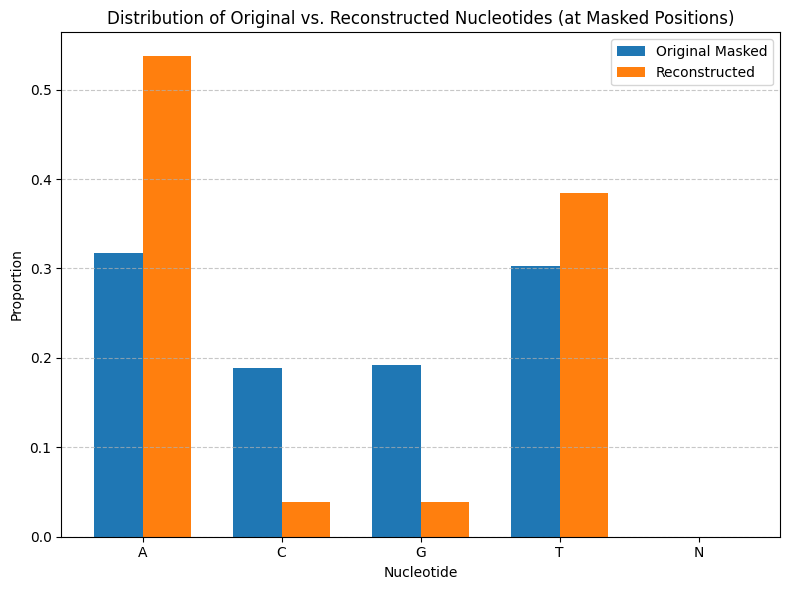

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

NUCLEOTIDE_MAP = {0: 'A', 1: 'C', 2: 'G', 3: 'T', 4: 'N'}

# --- Nucleotide Distribution Comparison ---
print("\n--- Comparing Nucleotide Distributions (Original vs. Reconstructed) ---")

# Ensures the model is in evaluation mode
model.eval()

all_original_masked_nucleotides = []
all_reconstructed_nucleotides = []

with torch.no_grad():
    for batch_idx, (model_input, original_nucleotide_labels, _, dna_target_mask, _) in enumerate(test_dataloader):
        model_input = model_input.to(device)
        original_nucleotide_labels = original_nucleotide_labels.to(device)
        dna_target_mask = dna_target_mask.to(device)


        try:
            dna_output, rna_output, third_output = model(model_input)


        except ValueError as e:
            print(f"Error unpacking model output: {e}")
            print(f"Model output type: {type(model(model_input))}")
            # If it's a tuple/list, print its length and types of elements
            if isinstance(model(model_input), (tuple, list)):
                print(f"Model output has {len(model(model_input))} elements.")
                for i, out_elem in enumerate(model(model_input)):
                    print(f"  Element {i} type: {type(out_elem)}")
                    if isinstance(out_elem, torch.Tensor):
                        print(f"  Element {i} shape: {out_elem.shape}")
            continue # Skip to next batch if unpacking fails

        # Extract original and reconstructed nucleotides at masked positions
        # Now that dna_output is correctly assigned, the rest should work
        masked_dna_logits = dna_output[dna_target_mask]
        masked_dna_true_labels = original_nucleotide_labels[dna_target_mask]

        if masked_dna_true_labels.numel() > 0:
            dna_predictions = torch.argmax(masked_dna_logits, dim=-1)

            all_original_masked_nucleotides.extend(masked_dna_true_labels.cpu().numpy())
            all_reconstructed_nucleotides.extend(dna_predictions.cpu().numpy())

# Convert lists to numpy arrays
all_original_masked_nucleotides = np.array(all_original_masked_nucleotides)
all_reconstructed_nucleotides = np.array(all_reconstructed_nucleotides)

# Calculate counts for each nucleotide
nucleotide_indices = np.arange(NUM_NUCLEOTIDES_ORIGINAL)

original_counts = np.bincount(all_original_masked_nucleotides, minlength=NUM_NUCLEOTIDES_ORIGINAL)
reconstructed_counts = np.bincount(all_reconstructed_nucleotides, minlength=NUM_NUCLEOTIDES_ORIGINAL)

# Normalize counts to get probabilities/distributions
original_distribution = original_counts / original_counts.sum() if original_counts.sum() > 0 else np.zeros(NUM_NUCLEOTIDES_ORIGINAL)
reconstructed_distribution = reconstructed_counts / reconstructed_counts.sum() if reconstructed_counts.sum() > 0 else np.zeros(NUM_NUCLEOTIDES_ORIGINAL)

print("Original Nucleotide Distribution (at masked positions):")
for i, count in enumerate(original_counts):
    print(f"  {NUCLEOTIDE_MAP.get(i, f'Unknown_{i}')}: {count} samples ({original_distribution[i]:.4f})")

print("\nReconstructed Nucleotide Distribution (at masked positions):")
for i, count in enumerate(reconstructed_counts):
    print(f"  {NUCLEOTIDE_MAP.get(i, f'Unknown_{i}')}: {count} samples ({reconstructed_distribution[i]:.4f})")


# Plotting the distributions
fig, ax = plt.subplots(figsize=(8, 6))

bar_width = 0.35
indices = np.arange(NUM_NUCLEOTIDES_ORIGINAL)

bars1 = ax.bar(indices - bar_width/2, original_distribution, bar_width, label='Original Masked')
bars2 = ax.bar(indices + bar_width/2, reconstructed_distribution, bar_width, label='Reconstructed')

ax.set_xlabel('Nucleotide')
ax.set_ylabel('Proportion')
ax.set_title('Distribution of Original vs. Reconstructed Nucleotides (at Masked Positions)')
ax.set_xticks(indices)
ax.set_xticklabels([NUCLEOTIDE_MAP.get(i, f'Unknown_{i}') for i in indices])
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('nucleotide_distribution_comparison.png')
print("Nucleotide distribution comparison plot saved as 'nucleotide_distribution_comparison.png'")

## 13 Generating Callibration Plots
In this section we generate callibration plots. These measure how well our transformer's predicted probabilities for the nucleotides align with the true likelihood of them being at a specific position.


--- Generating Calibration Plots for Each Nucleotide ---
Combined calibration plots saved as 'calibration_plots_all_nucleotides.png'


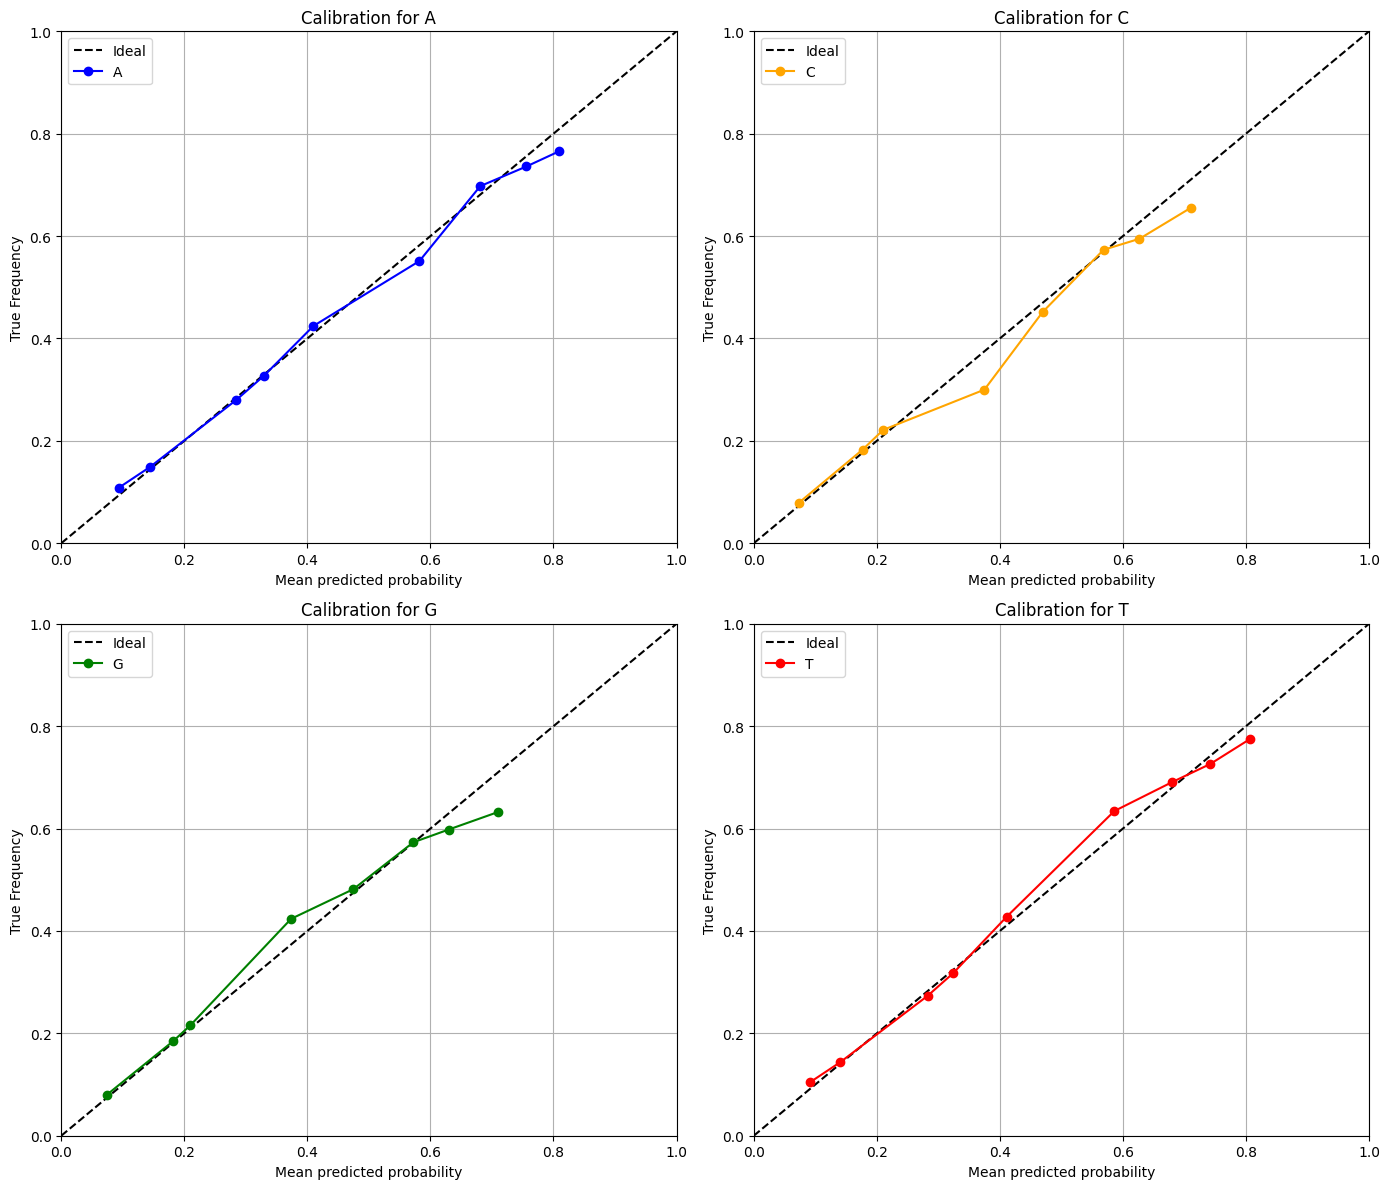


All calibration plots generated.


In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict


NUCLEOTIDE_MAP = {0: 'A', 1: 'C', 2: 'G', 3: 'T', 4: 'N'}
NUM_NUCLEOTIDES_ORIGINAL = len(NUCLEOTIDE_MAP)

# Define custom colors for better visual distinction
NUCLEOTIDE_COLORS = {
    'A': 'blue',
    'C': 'orange',
    'G': 'green',
    'T': 'red'
}


# --- Calibration Plot Setup ---
print("\n--- Generating Calibration Plots for Each Nucleotide ---")

# Ensures the model is in evaluation mode
model.eval()

# Store predicted probabilities and true labels for masked positions
all_masked_probs_by_nucleotide = defaultdict(lambda: {'probabilities': [], 'true_labels': []})

with torch.no_grad():
    for batch_idx, (model_input, original_nucleotide_labels, _, dna_target_mask, _) in enumerate(test_dataloader):
        model_input = model_input.to(device)
        original_nucleotide_labels = original_nucleotide_labels.to(device)
        dna_target_mask = dna_target_mask.to(device)

        try:
            dna_output, rna_output, third_output = model(model_input)
        except ValueError as e:
            print(f"Error unpacking model output: {e}")

            continue

        # Get logits and true labels for masked positions
        masked_dna_logits = dna_output[dna_target_mask]
        masked_dna_true_labels = original_nucleotide_labels[dna_target_mask]

        if masked_dna_true_labels.numel() > 0:
            masked_dna_probabilities = torch.softmax(masked_dna_logits, dim=-1)

            for i in range(masked_dna_true_labels.shape[0]):
                true_label = masked_dna_true_labels[i].item()
                predicted_probs = masked_dna_probabilities[i].cpu().numpy()

                for nuc_idx in range(NUM_NUCLEOTIDES_ORIGINAL):
                    nucleotide_char = NUCLEOTIDE_MAP.get(nuc_idx)
                    # Skip 'N'
                    if nucleotide_char == 'N':
                        continue

                    prob_for_this_nuc = predicted_probs[nuc_idx]
                    is_true_nuc = 1 if true_label == nuc_idx else 0
                    all_masked_probs_by_nucleotide[nuc_idx]['probabilities'].append(prob_for_this_nuc)
                    all_masked_probs_by_nucleotide[nuc_idx]['true_labels'].append(is_true_nuc)

# --- Generate and Plot Calibration Curves for Each Nucleotide in a Subplot Layout ---
num_bins = 10 # Increased number of bins for more points on the plot

# Define the layout of subplots (e.g., 2 rows, 2 columns for A, C, G, T)
n_rows = 2
n_cols = 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 12)) # Adjust figure size as needed
axes = axes.flatten() # Flatten the 2x2 array of axes for easier iteration

plot_idx = 0
for nuc_idx in sorted(all_masked_probs_by_nucleotide.keys()): # Sort keys for consistent plot order
    nucleotide_name = NUCLEOTIDE_MAP.get(nuc_idx)

    # Ensure we only plot A, C, G, T
    if nucleotide_name not in ['A', 'C', 'G', 'T']:
        continue

    data = all_masked_probs_by_nucleotide[nuc_idx]
    probabilities = np.array(data['probabilities'])
    true_labels = np.array(data['true_labels'])

    if len(probabilities) == 0:
        print(f"No data for nucleotide: {nucleotide_name}. Skipping calibration plot.")
        continue

    bin_edges = np.linspace(0.0, 1.0, num_bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    avg_predicted_probs = []
    observed_accuracies = []


    for i in range(num_bins):
        if i == num_bins - 1:
            bin_mask = (probabilities >= bin_edges[i]) & (probabilities <= bin_edges[i+1])
        else:
            bin_mask = (probabilities >= bin_edges[i]) & (probabilities < bin_edges[i+1])

        bin_probs = probabilities[bin_mask]
        bin_true_labels = true_labels[bin_mask]

        if len(bin_probs) > 0:
            avg_predicted_probs.append(np.mean(bin_probs))
            observed_accuracies.append(np.mean(bin_true_labels))
        else:
            avg_predicted_probs.append(np.nan) # Use NaN for x-value if bin is empty
            observed_accuracies.append(np.nan)

    # Filter out bins with no data for plotting
    plot_x = [p for p in avg_predicted_probs if not np.isnan(p)]
    plot_y = [acc for acc in observed_accuracies if not np.isnan(acc)]

    # Get the current subplot axis
    ax = axes[plot_idx]
    current_color = NUCLEOTIDE_COLORS.get(nucleotide_name, 'black')

    # Plot the ideal calibration line (diagonal)
    ax.plot([0, 1], [0, 1], linestyle='--', color='black', label='Ideal')

    # Plot the actual calibration curve
    if len(plot_x) > 0:
        # Use a dot for the marker, and connect the dots with a line
        ax.plot(plot_x, plot_y, marker='o', linestyle='-', color=current_color, label=f'{nucleotide_name}')

    ax.set_xlabel('Mean predicted probability')
    ax.set_title(f'Calibration for {nucleotide_name}')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(True)
    ax.legend(loc='upper left')

    plot_idx += 1


for i in range(plot_idx, n_rows * n_cols):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.savefig('calibration_plots_all_nucleotides.png')
print("Combined calibration plots saved as 'calibration_plots_all_nucleotides.png'")
plt.show()

print("\nAll calibration plots generated.")

## 14. Plotting Sequence Logos and Expression Prediction for Two Example Chromosomes

In this section, we visualize **sequence logos** for two chromosome regions:  
**`chrIV:1468900..1469900`** and **`chrIX:47250..48250`**.

These plots help us understand how confident the model is in its predictions.

---

For each example, we generate:

- Two **sequence logos**, for 2 parts of the sequence where the model is the most confident.
- The **ground truth sequence** below, allowing direct comparison with predictions.

---

Additionally, we display the model's **expression level predictions** beneath each logo, providing further insight into the model's behavior, especially to see how it performs on the border between an expressed and unexpressed state.

---

We also added the feature that you can click on the Genome Browser link below the plots to see the corresponding region in a genome browser.

---
Part of the RNA sequence was masked, which is shown by a greyed out part. In the report, we compared this to prediction without masking. We can see that parts that are masked struggle to predict expression value compared to unmasked parts.



--- Finding and Plotting High Certainty Sub-Regions for Example Regions ---

Analyzing certainty for chrIV:1468900-1469900...


/tmp/ipython-input-20-1025369306.py:124: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Found 2 most certain 50-base sub-segments in chrIV:1468900-1469900:
  Sub-segment 1: Relative positions 166-216 (Genomic: chrIV:1469066-1469116), Avg Certainty: 0.8271


/tmp/ipython-input-20-1025369306.py:204: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(): # Use AMP if available
/usr/local/lib/python3.11/dist-packages/logomaker/src/error_handling.py:58: UserWarning:  Warning: Character 'N' is not in color_dict. Using black.
  warnings.warn(str(Error))



UCSC Genome Browser link for this region: https://genome.ucsc.edu/cgi-bin/hgTracks?db=sacCer3&position=chrIV%3A1469066-1469116
Copy and paste the URL into your browser to view the region in a genome browser.


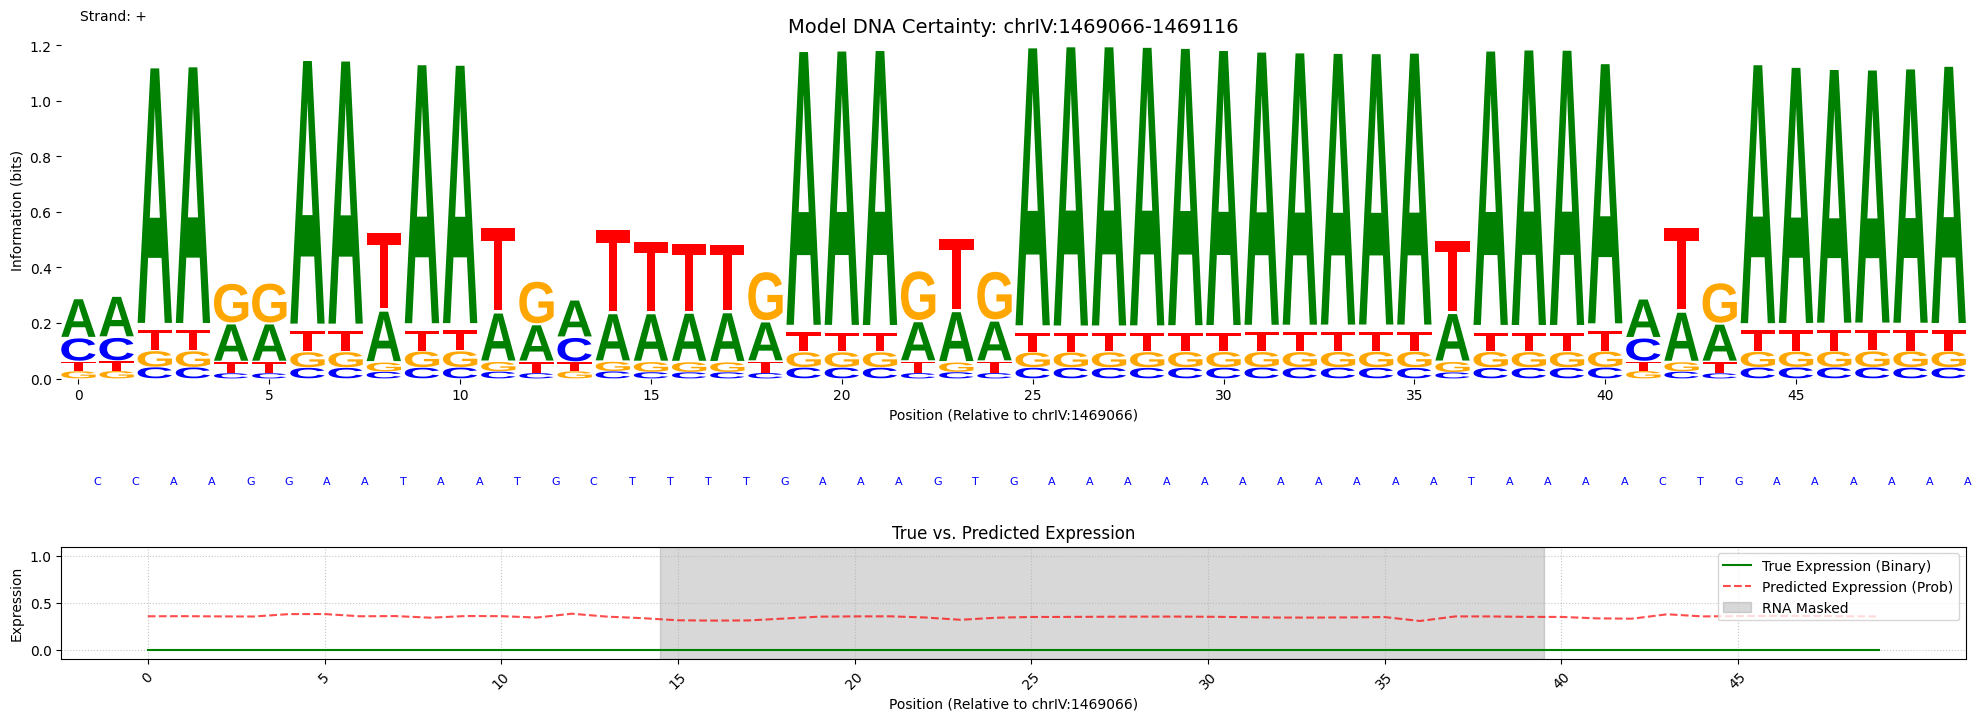

Sequence logo and expression plot saved to certainty_logo_chrIV_1469066_1469116.png
  Sub-segment 2: Relative positions 167-217 (Genomic: chrIV:1469067-1469117), Avg Certainty: 0.8237


/tmp/ipython-input-20-1025369306.py:204: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(): # Use AMP if available
/usr/local/lib/python3.11/dist-packages/logomaker/src/error_handling.py:58: UserWarning:  Warning: Character 'N' is not in color_dict. Using black.
  warnings.warn(str(Error))



UCSC Genome Browser link for this region: https://genome.ucsc.edu/cgi-bin/hgTracks?db=sacCer3&position=chrIV%3A1469067-1469117
Copy and paste the URL into your browser to view the region in a genome browser.


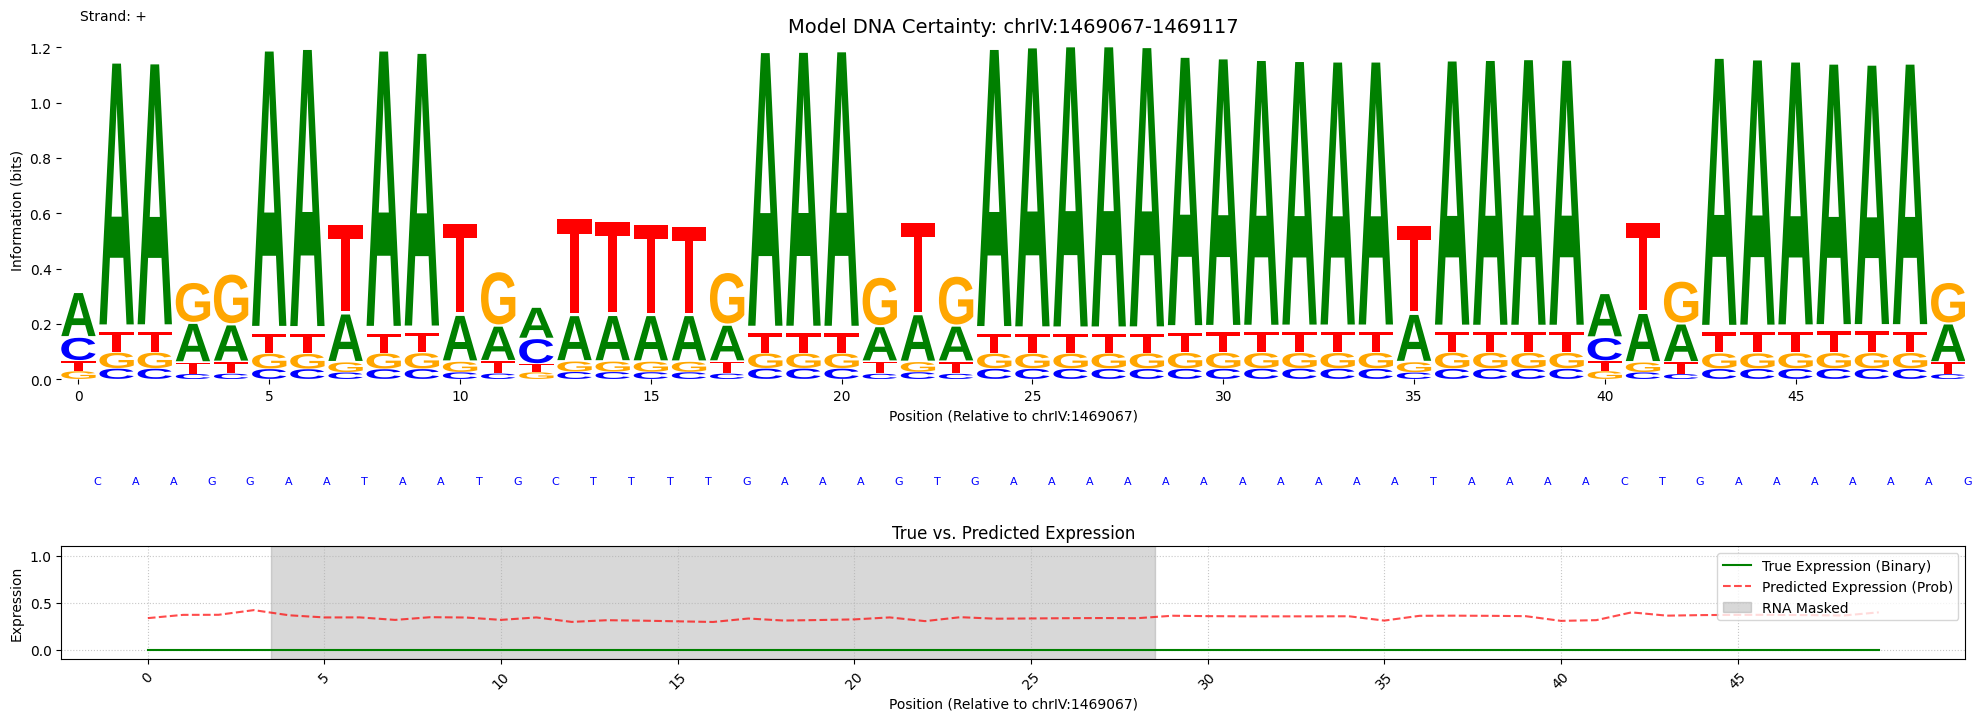

Sequence logo and expression plot saved to certainty_logo_chrIV_1469067_1469117.png

Analyzing certainty for chrIX:47250-48250...


/tmp/ipython-input-20-1025369306.py:124: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Found 2 most certain 50-base sub-segments in chrIX:47250-48250:
  Sub-segment 1: Relative positions 402-452 (Genomic: chrIX:47652-47702), Avg Certainty: 0.7783


/tmp/ipython-input-20-1025369306.py:204: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(): # Use AMP if available
/usr/local/lib/python3.11/dist-packages/logomaker/src/error_handling.py:58: UserWarning:  Warning: Character 'N' is not in color_dict. Using black.
  warnings.warn(str(Error))



UCSC Genome Browser link for this region: https://genome.ucsc.edu/cgi-bin/hgTracks?db=sacCer3&position=chrIX%3A47652-47702
Copy and paste the URL into your browser to view the region in a genome browser.


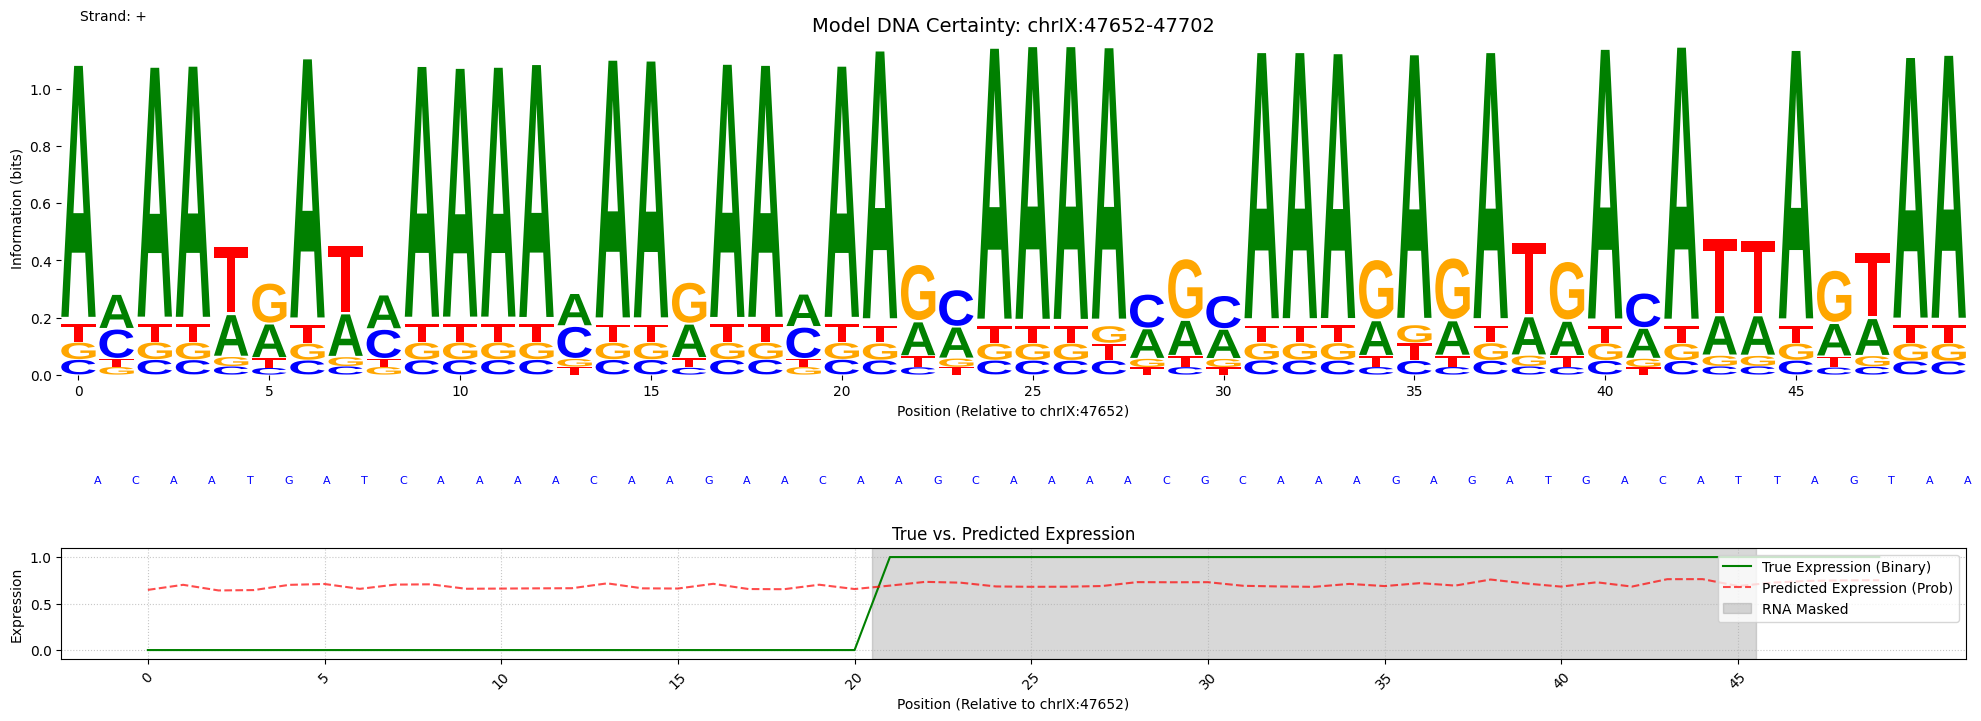

Sequence logo and expression plot saved to certainty_logo_chrIX_47652_47702.png
  Sub-segment 2: Relative positions 391-441 (Genomic: chrIX:47641-47691), Avg Certainty: 0.7744


/tmp/ipython-input-20-1025369306.py:204: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(): # Use AMP if available
/usr/local/lib/python3.11/dist-packages/logomaker/src/error_handling.py:58: UserWarning:  Warning: Character 'N' is not in color_dict. Using black.
  warnings.warn(str(Error))



UCSC Genome Browser link for this region: https://genome.ucsc.edu/cgi-bin/hgTracks?db=sacCer3&position=chrIX%3A47641-47691
Copy and paste the URL into your browser to view the region in a genome browser.


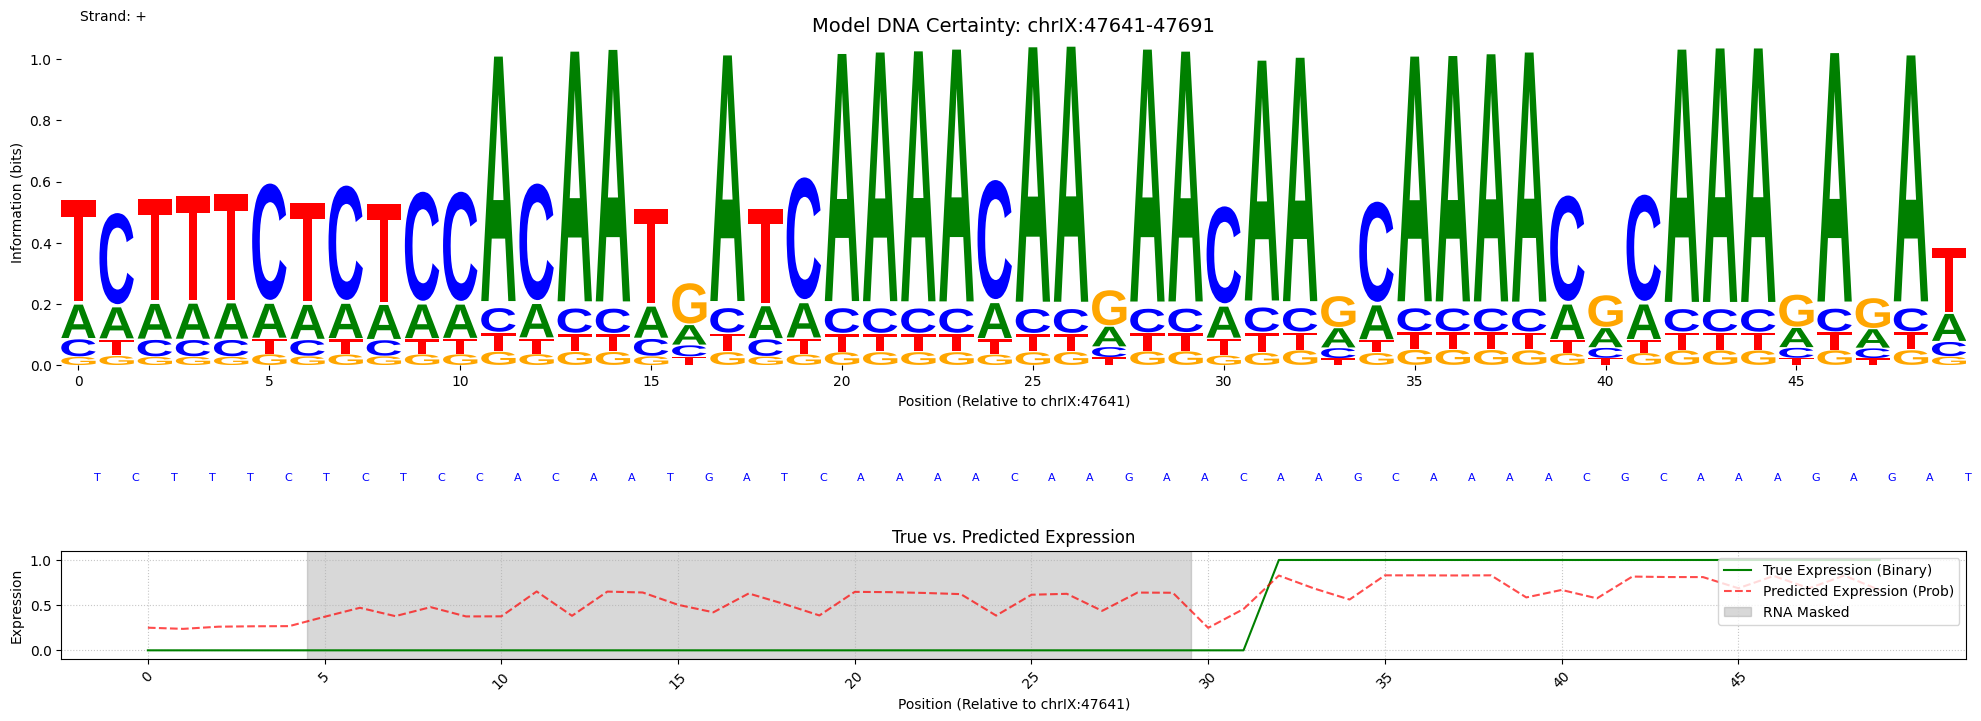

Sequence logo and expression plot saved to certainty_logo_chrIX_47641_47691.png
--- High Certainty Sub-Region Analysis Complete ---


In [ ]:
# --- Helper Functions for Sequence Logo Plotting ---

def one_hot_encode_nucleotides_for_inference(sequence_segment_int, target_one_hot_dim):
    """
    Helper to one-hot encode nucleotide integer indices for model input (0-4 for A,C,G,T,N).
    This version is for inference, so it doesn't use the MASK_NUCLEOTIDE_INDEX for actual sequence positions.
    """
    one_hot_tensor = torch.zeros(len(sequence_segment_int), target_one_hot_dim, dtype=torch.float32)
    one_hot_tensor.scatter_(1, sequence_segment_int.unsqueeze(1).long(), 1)
    return one_hot_tensor

def get_sequence_and_expression_for_range(base_dataset, chromosome: str, start: int, end: int):
    """
    Retrieves the DNA sequence (integer-encoded) and expression labels for a specific genomic range.
    This function iterates through regions_df to find the segment that contains the requested range.
    It then extracts the relevant portion of the sequence and expression data,
    correcting for strand if necessary.
    """
    target_length = end - start

    # Iterate through regions_df to find the relevant region
    for idx in range(len(base_dataset.regions_df)):
        region_info = base_dataset.regions_df.iloc[idx]
        region_chrom = region_info['contig']
        region_offset = region_info['offset'] # Start of this region in the global np.array
        region_window_size = region_info['window_size']
        region_strand = region_info['strand']

        region_genomic_start = region_info['start'] # Genomic start from parquet
        region_genomic_end = region_info['start'] + region_info['window_size']  # Genomic end from parquet

        # Check if this region's genomic coordinates entirely contain the requested range
        if region_chrom == chromosome and region_genomic_start <= start and region_genomic_end >= end:
            # This region covers the requested span

            # Extract the full window data as it would be processed by __getitem__
            full_window_nuc_raw = base_dataset.sequence_data[region_offset : region_offset + region_window_size].copy()
            full_window_exp_plus_raw = base_dataset.expression_plus_data[region_offset : region_offset + region_window_size].copy()
            full_window_exp_minus_raw = base_dataset.expression_minus_data[region_offset : region_offset + region_window_size].copy()

            if region_strand == '+':
                processed_nuc_full = full_window_nuc_raw
                processed_exp_full = full_window_exp_plus_raw
            else: # strand == '-'
                # Apply reverse complement to the full DNA sequence of this window
                # And then reverse the order to match genomic coordinates
                processed_nuc_full = base_dataset.complement_map[full_window_nuc_raw[::-1]].copy()
                processed_exp_full = full_window_exp_minus_raw[::-1] # Reverse expression for minus strand

            # Calculate the sub-segment indices within the *processed full window*
            offset_in_window = start - region_genomic_start

            original_nucleotide_segment_int = processed_nuc_full[offset_in_window : offset_in_window + target_length]
            original_expression_label_segment = processed_exp_full[offset_in_window : offset_in_window + target_length]

            return (
                torch.tensor(original_nucleotide_segment_int, dtype=torch.long),
                torch.tensor(original_expression_label_segment, dtype=torch.float32),
                region_strand,
                region_offset # Return the original offset for reference
            )

    print(f"No single region found in dataset that covers {chromosome}:{start}-{end} entirely.")
    return None, None, None, None

def find_most_certain_subsegments_in_region(model, original_nucleotide_labels_int, original_expression_labels,
                                             device, num_subsegments=2, subsegment_length=50):
    """
    Identifies sub-segments within a given sequence where the model's DNA nucleotide predictions
    have the highest certainty (information content).

    """
    # Set device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    model.eval()
    sequence_length = len(original_nucleotide_labels_int)
    all_subsegment_certainties = []

    # Iterate with a sliding window
    for i in range(0, sequence_length - subsegment_length + 1):
        sub_nuc_labels = original_nucleotide_labels_int[i : i + subsegment_length]
        sub_exp_labels = original_expression_labels[i : i + subsegment_length]

        # Prepare input for the model (unmasked DNA + expression)
        input_nucleotide_features = one_hot_encode_nucleotides_for_inference(sub_nuc_labels, ONE_HOT_NUCLEOTIDE_DIM)
        input_expression_states = sub_exp_labels.unsqueeze(-1)
        model_input = torch.cat((input_nucleotide_features, input_expression_states), dim=-1)
        model_input = model_input.unsqueeze(0).to(device)

        with torch.no_grad():
            with autocast():
                dna_logits, _, _ = model(model_input)

        dna_probabilities = torch.softmax(dna_logits.squeeze(0).cpu(), dim=-1).numpy()

        # Calculate entropy per position
        entropy = -np.sum(dna_probabilities * np.log2(dna_probabilities + 1e-8), axis=1)
        # Max entropy for 4 bases is 2 bits (assuming A,C,G,T for information content, N is ignored or handled as uniform)
        information_content = 2.0 - entropy

        avg_certainty = np.mean(information_content)

        all_subsegment_certainties.append({
            'relative_start': i,
            'avg_certainty': avg_certainty
        })

    # Sort by certainty and get top N
    all_subsegment_certainties.sort(key=lambda x: x['avg_certainty'], reverse=True)
    top_subsegments = all_subsegment_certainties[:num_subsegments]

    return top_subsegments

def apply_rna_masking_for_plotting(original_expression_labels: torch.Tensor, rna_mask_fraction: float):
    """
    Applies contiguous RNA masking similar to MultiModalMaskingDataset for plotting purposes.
    Returns the masked expression values and a boolean mask indicating masked positions.
    """
    masked_expression = original_expression_labels.clone()
    rna_mask_applied = torch.full_like(original_expression_labels, False, dtype=torch.bool)
    seq_length = len(original_expression_labels)

    rna_mask_span_length = max(1, int(seq_length * rna_mask_fraction))
    if seq_length > rna_mask_span_length:
        rna_mask_start_idx = random.randint(0, seq_length - rna_mask_span_length)
    else:
        rna_mask_start_idx = 0
        rna_mask_span_length = seq_length
    rna_mask_end_idx = rna_mask_start_idx + rna_mask_span_length

    masked_expression[rna_mask_start_idx : rna_mask_end_idx] = MASK_EXPRESSION_VALUE # Use the defined mask value
    rna_mask_applied[rna_mask_start_idx : rna_mask_end_idx] = True
    return masked_expression, rna_mask_applied


def plot_sequence_logo(model, original_nucleotide_labels_int, original_expression_labels, rna_mask_applied,
                       strand, chromosome, start, end, title, output_filename="sequence_logo.png",
                       plot_start_rel=0, plot_end_rel=None):
    """
    Plots a sequence logo showing the model's predicted nucleotide probabilities
    for a given genomic region, and compares it with true expression.
    Also provides a UCSC Genome Browser link.

    """
    model.eval() # Set model to evaluation mode
    # Use the masked expression as input to the model during inference for plotting
    masked_expression_input_for_model = original_expression_labels.clone()
    masked_expression_input_for_model[rna_mask_applied] = MASK_EXPRESSION_VALUE

    input_nucleotide_features = one_hot_encode_nucleotides_for_inference(original_nucleotide_labels_int, ONE_HOT_NUCLEOTIDE_DIM)
    input_expression_states_for_inference = masked_expression_input_for_model.unsqueeze(-1) # Use the *masked* expression for model input here!
    model_input = torch.cat((input_nucleotide_features, input_expression_states_for_inference), dim=-1)
    model_input = model_input.unsqueeze(0).to(device)

    with torch.no_grad(): # No need to calculate gradients for inference
        with autocast(): # Use AMP if available
            dna_logits, expression_logits, _ = model(model_input) # Get both DNA and expression logits

    # Remove batch dimension and move to CPU
    dna_logits = dna_logits.squeeze(0).cpu()
    expression_logits = expression_logits.squeeze(0).cpu()

    # Convert logits to probabilities using softmax for DNA
    dna_probabilities = torch.softmax(dna_logits, dim=-1)

    # Convert expression logits to probabilities (if binary) or just use them
    expression_probabilities = torch.sigmoid(expression_logits).squeeze(-1) # (seq_len,)

    # --- Apply plot_start_rel and plot_end_rel for slicing ---
    if plot_end_rel is None:
        plot_end_rel = len(original_nucleotide_labels_int) # Plot to the end of the retrieved sequence

    # Ensure plot_start_rel and plot_end_rel are within valid bounds
    plot_start_rel = max(0, plot_start_rel)
    plot_end_rel = min(len(original_nucleotide_labels_int), plot_end_rel)

    # Slice the data for plotting
    dna_probabilities_to_plot = dna_probabilities[plot_start_rel:plot_end_rel]
    original_nucleotide_labels_to_plot = original_nucleotide_labels_int[plot_start_rel:plot_end_rel]
    expression_probabilities_to_plot = expression_probabilities[plot_start_rel:plot_end_rel]
    true_expression_labels_to_plot = original_expression_labels[plot_start_rel:plot_end_rel]
    rna_mask_to_plot = rna_mask_applied[plot_start_rel:plot_end_rel]


    # Convert to NumPy array for easier math
    p = dna_probabilities_to_plot.numpy()

    # Calculate entropy per position
    entropy = -np.sum(p * np.log2(p + 1e-8), axis=1)  # Avoid log(0)

    # Compute information content: max entropy (2 bits for DNA) minus entropy
    information_content = 2.0 - entropy  # shape: (sequence length,)

    # Scale each base by its information content
    info_scaled = p * information_content[:, np.newaxis]  # (L, 4) * (L, 1)

    # Create DataFrame for logomaker
    logo_df = pd.DataFrame(info_scaled, columns=NUCLEOTIDE_CHARS[:NUM_NUCLEOTIDES_ORIGINAL])

    # --- Plotting ---
    plot_length = plot_end_rel - plot_start_rel
    fig_width = max(12, plot_length * 0.4) # Adjusted scaling factor

    # Create a figure with two subplots: one for logo, one for expression
    fig, (ax_logo, ax_expression) = plt.subplots(2, 1, figsize=(fig_width, 8), gridspec_kw={'height_ratios': [3, 1]})

    # --- Sequence Logo Plot (Top Subplot) ---
    logo = logomaker.Logo(logo_df,
                          ax=ax_logo, # Pass the subplot axis
                          font_name='Liberation Sans',
                          vpad=.05,
                          width=.9,
                          fade_below=.5,
                          color_scheme='classic')

    logo.style_spines(visible=False)

    # Determine appropriate tick interval based on plot_length
    if plot_length <= 20:
        tick_interval = 1
    elif plot_length <= 50:
        tick_interval = 5
    else:
        tick_interval = 10

    ax_logo.set_xticks(np.arange(0, plot_length, tick_interval))
    # Adjust x-tick labels to reflect absolute positions within the *original full segment*
    ax_logo.set_xticklabels(np.arange(plot_start_rel, plot_end_rel, tick_interval))

    ax_logo.set_ylabel('Information (bits)', color='black')
    ax_logo.set_xlabel(f'Position (Relative to {chromosome}:{start})', color='black')

    # Add true sequence characters below the logo
    true_sequence_chars = [NUCLEOTIDE_MAP_INT_TO_CHAR[n.item()] for n in original_nucleotide_labels_to_plot]
    for i, char in enumerate(true_sequence_chars):
        ax_logo.text(i + 0.5, -0.35, char, ha='center', va='top', fontsize=8, color='blue')

    ax_logo.text(0.01, 1.05, f"Strand: {strand}", transform=ax_logo.transAxes, ha='left', va='bottom', fontsize=10)
    ax_logo.set_title(title, fontsize=14) # Smaller title for subplot

    # --- True Expression Plot (Bottom Subplot - "Genome Browser" like) ---
    ax_expression.plot(range(plot_length), true_expression_labels_to_plot.numpy(), color='green', label='True Expression (Binary)')
    ax_expression.plot(range(plot_length), expression_probabilities_to_plot.numpy(), color='red', linestyle='--', alpha=0.7, label='Predicted Expression (Prob)')

    # Highlight masked RNA regions
    masked_indices = torch.where(rna_mask_to_plot)[0]
    if len(masked_indices) > 0:
        # Find contiguous masked spans
        starts = []
        ends = []
        if len(masked_indices) > 0:
            current_start = masked_indices[0]
            for i in range(1, len(masked_indices)):
                if masked_indices[i] == masked_indices[i-1] + 1:
                    continue
                else:
                    starts.append(current_start)
                    ends.append(masked_indices[i-1] + 1)
                    current_start = masked_indices[i]
            starts.append(current_start)
            ends.append(masked_indices[-1] + 1)

        for s, e in zip(starts, ends):
            ax_expression.axvspan(s - 0.5, e - 0.5, color='gray', alpha=0.3, label='RNA Masked' if s == starts[0] else "")


    ax_expression.set_xticks(np.arange(0, plot_length, tick_interval))
    ax_expression.set_xticklabels(np.arange(plot_start_rel, plot_end_rel, tick_interval))
    ax_expression.set_xlabel(f'Position (Relative to {chromosome}:{start})', color='black')
    ax_expression.set_ylabel('Expression', color='black')
    ax_expression.set_title('True vs. Predicted Expression', fontsize=12)
    ax_expression.set_ylim(-0.1, 1.1) # Ensure y-axis covers 0 and 1
    ax_expression.legend(loc='upper right')
    ax_expression.grid(True, linestyle=':', alpha=0.7)
    ax_expression.tick_params(axis='x', rotation=45) # Rotate x-axis labels for readability

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent overlap and make space for main title

    # --- UCSC Genome Browser Link ---
    ucsc_url = f"https://genome.ucsc.edu/cgi-bin/hgTracks?db=sacCer3&position={chromosome}%3A{start}-{end}"
    print(f"\nUCSC Genome Browser link for this region: {ucsc_url}")
    print("Copy and paste the URL into your browser to view the region in a genome browser.")

    plt.savefig(output_filename)
    plt.show()
    print(f"Sequence logo and expression plot saved to {output_filename}")

import os


MODEL_SAVE_PATH = '/content/gdrive/My Drive/my_best_models/best_transformer_model.pth'

start_epoch = 1
best_val_loss = float('inf')

if os.path.exists(MODEL_SAVE_PATH):
  checkpoint = torch.load(MODEL_SAVE_PATH, map_location=device)

  model.load_state_dict(checkpoint['model_state_dict'])
  optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
  if 'scheduler_state_dict' in checkpoint and checkpoint['scheduler_state_dict'] is not None:
      scheduler.load_state_dict(checkpoint['scheduler_state_dict'])

  start_epoch = checkpoint['epoch'] + 1
  best_val_loss = checkpoint['best_val_loss']

  # Load previous metric histories
  train_total_losses = checkpoint.get('train_total_losses', []) # Use .get with default [] for robustness
  val_total_losses = checkpoint.get('val_total_losses', [])
  train_dna_losses = checkpoint.get('train_dna_losses', [])
  val_dna_losses = checkpoint.get('val_dna_losses', [])
  train_rna_losses = checkpoint.get('train_rna_losses', [])
  val_rna_losses = checkpoint.get('val_rna_losses', [])
  train_dna_accuracies = checkpoint.get('train_dna_accuracies', [])
  val_dna_accuracies = checkpoint.get('val_dna_accuracies', [])
  train_rna_accuracies = checkpoint.get('train_rna_accuracies', [])
  val_rna_accuracies = checkpoint.get('val_rna_accuracies', [])
# Set model to evaluation mode
model.eval()

print("\n--- Finding and Plotting High Certainty Sub-Regions for Example Regions ---")

# Example 1: chrIV:1468900..1469900
chr4_start_genomic = 1468900
chr4_end_genomic = 1469900
chr4_chrom = 'chrIV'

original_nucleotide_labels_int_chr4, original_expression_labels_chr4, strand_chr4, _ = \
    get_sequence_and_expression_for_range(base_full_dataset, chr4_chrom, chr4_start_genomic, chr4_end_genomic)

if original_nucleotide_labels_int_chr4 is not None:
    print(f"\nAnalyzing certainty for {chr4_chrom}:{chr4_start_genomic}-{chr4_end_genomic}...")

    top_certain_subsegments_chr4 = find_most_certain_subsegments_in_region(
        model, original_nucleotide_labels_int_chr4, original_expression_labels_chr4,
        device, num_subsegments=2, subsegment_length=50
    )

    if top_certain_subsegments_chr4:
        print(f"Found {len(top_certain_subsegments_chr4)} most certain 50-base sub-segments in {chr4_chrom}:{chr4_start_genomic}-{chr4_end_genomic}:")
        for i, subsegment in enumerate(top_certain_subsegments_chr4):
            sub_start_rel = subsegment['relative_start']
            sub_end_rel = sub_start_rel + 50

            sub_start_genomic = chr4_start_genomic + sub_start_rel
            sub_end_genomic = chr4_start_genomic + sub_end_rel

            print(f"  Sub-segment {i+1}: Relative positions {sub_start_rel}-{sub_end_rel} (Genomic: {chr4_chrom}:{sub_start_genomic}-{sub_end_genomic}), Avg Certainty: {subsegment['avg_certainty']:.4f}")

            # Extract the actual sub-segment data for plotting
            nucleotides_for_plot = original_nucleotide_labels_int_chr4[sub_start_rel:sub_end_rel]
            expression_for_plot = original_expression_labels_chr4[sub_start_rel:sub_end_rel]

            # Do not apply RNA masking specifically for this plot's demonstration
            rna_mask_for_plot = torch.full_like(expression_for_plot, False, dtype=torch.bool)



            plot_sequence_logo(
                model,
                nucleotides_for_plot,  # Pass only the 50-base sub-segment
                expression_for_plot,   # Pass only the 50-base sub-segment (unmasked true values)
                rna_mask_for_plot,     # Pass the RNA mask for highlighting
                strand_chr4,
                chr4_chrom,
                sub_start_genomic,     # Pass the *actual genomic start* of this sub-segment
                sub_end_genomic,       # Pass the *actual genomic end* of this sub-segment
                f"Model DNA Certainty: {chr4_chrom}:{sub_start_genomic}-{sub_end_genomic}",
                f"certainty_logo_{chr4_chrom}_{sub_start_genomic}_{sub_end_genomic}.png",
                plot_start_rel=0,      # Now, the relative start is always 0 for the passed segment
                plot_end_rel=None      # And plot to the end of this 50-base segment
            )
    else:
        print(f"No certain sub-segments found for {chr4_chrom}:{chr4_start_genomic}-{chr4_end_genomic}.")
else:
    pass # No need for an additional print here, as get_sequence_and_expression_for_range already prints a message


# Example 2: chrIX:47250..48250
chr9_start_genomic = 47250
chr9_end_genomic = 48250
chr9_chrom = 'chrIX'

original_nucleotide_labels_int_chr9, original_expression_labels_chr9, strand_chr9, _ = \
    get_sequence_and_expression_for_range(base_full_dataset, chr9_chrom, chr9_start_genomic, chr9_end_genomic)

if original_nucleotide_labels_int_chr9 is not None:
    print(f"\nAnalyzing certainty for {chr9_chrom}:{chr9_start_genomic}-{chr9_end_genomic}...")

    top_certain_subsegments_chr9 = find_most_certain_subsegments_in_region(
        model, original_nucleotide_labels_int_chr9, original_expression_labels_chr9,
        device, num_subsegments=2, subsegment_length=50
    )

    if top_certain_subsegments_chr9:
        print(f"Found {len(top_certain_subsegments_chr9)} most certain 50-base sub-segments in {chr9_chrom}:{chr9_start_genomic}-{chr9_end_genomic}:")
        for i, subsegment in enumerate(top_certain_subsegments_chr9):
            sub_start_rel = subsegment['relative_start']
            sub_end_rel = sub_start_rel + 50

            sub_start_genomic = chr9_start_genomic + sub_start_rel
            sub_end_genomic = chr9_start_genomic + sub_end_rel

            print(f"  Sub-segment {i+1}: Relative positions {sub_start_rel}-{sub_end_rel} (Genomic: {chr9_chrom}:{sub_start_genomic}-{sub_end_genomic}), Avg Certainty: {subsegment['avg_certainty']:.4f}")

            # Extract the actual sub-segment data for plotting
            nucleotides_for_plot = original_nucleotide_labels_int_chr9[sub_start_rel:sub_end_rel]
            expression_for_plot = original_expression_labels_chr9[sub_start_rel:sub_end_rel]

            # Apply RNA masking specifically for this plot's demonstration
            _, rna_mask_for_plot = apply_rna_masking_for_plotting(expression_for_plot, RNA_MASK_FRACTION)

            plot_sequence_logo(
                model,
                nucleotides_for_plot,  # Pass only the 50-base sub-segment
                expression_for_plot,   # Pass only the 50-base sub-segment
                rna_mask_for_plot,     # Pass the RNA mask for highlighting
                strand_chr9,
                chr9_chrom,
                sub_start_genomic,     # Pass the *actual genomic start* of this sub-segment
                sub_end_genomic,       # Pass the *actual genomic end* of this sub-segment
                f"Model DNA Certainty: {chr9_chrom}:{sub_start_genomic}-{sub_end_genomic}",
                f"certainty_logo_{chr9_chrom}_{sub_start_genomic}_{sub_end_genomic}.png",
                plot_start_rel=0,      # Now, the relative start is always 0 for the passed segment
                plot_end_rel=None      # And plot to the end of this 50-base segment
            )
    else:
        print(f"No certain sub-segments found for {chr9_chrom}:{chr9_start_genomic}-{chr9_end_genomic}.")
else:
    pass

print("--- High Certainty Sub-Region Analysis Complete ---")

## 15. Assessing Model Performance vs. Random Guessing

### 15.1 DNA Nucleotide Prediction (Multi-Class)

We examine nucleotide frequency distributions to estimate what random guessing would achieve and detect class imbalances that may affect predictions.

### 15.2 RNA Expression Prediction (Binary)

We analyze the frequency of expressed vs. non-expressed RNA values to assess dataset imbalance.

---

### 15.3 Evaluation Metrics

**F1 Score** – Balances precision and recall, ideal for imbalanced datasets:

$$
F1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}
$$

- **Precision**:
$$
\frac{TP}{TP + FP}
$$

- **Recall** (Sensitivity):
$$
\frac{TP}{TP + FN}
$$

**ROC AUC** – Threshold-independent metric for binary classification:

- **ROC Curve**:
Plots True Positive Rate (TPR) vs. False Positive Rate (FPR):

$$
TPR = \frac{TP}{TP + FN}, \quad FPR = \frac{FP}{FP + TN}
$$

- **AUC**: Measures separability between classes.
1 = perfect, 0.5 = random guessing.

ROC AUC is robust for imbalanced data.


In [ ]:
# --- PART 1: Calculate Nucleotide Frequencies (for Stratified Random DNA) ---
nucleotide_counts = Counter()
total_nucleotides = 0
MODEL_SAVE_PATH = '/content/gdrive/My Drive/my_best_models/best_transformer_model.pth'
model, optimizer, scheduler, metadata = load_model_checkpoint(model, optimizer, scheduler, MODEL_SAVE_PATH, device)

for idx in train_subset_indices.indices: # Use .indices for Subset
    original_dna_seq, _ = base_full_dataset[idx]
    nucleotide_counts.update(original_dna_seq.tolist())
    total_nucleotides += len(original_dna_seq)

nucleotide_proportions = {n: count / total_nucleotides for n, count in nucleotide_counts.items()}
print("DNA Nucleotide Proportions in Training Data (for stratified baseline):", nucleotide_proportions)


# --- PART 2: Calculate RNA Expression Frequencies (for Stratified Random RNA) ---
expression_counts = Counter()
total_expressions = 0

for idx in train_subset_indices.indices: # Use .indices for Subset
    _, original_rna_labels = base_full_dataset[idx]
    expression_counts.update(original_rna_labels.to(torch.int).tolist())
    total_expressions += len(original_rna_labels)

expression_proportions = {state: count / total_expressions for state, count in expression_counts.items()}
print("RNA Expression Proportions in Training Data (for stratified baseline):", expression_proportions)


# --- PART 3: Evaluate Stratified Random Baselines on Test Set and Calculate Expected Values ---
dna_random_stratified_predictions = []
dna_true_labels_masked_positions = []

rna_random_stratified_predictions = []
rna_true_labels_masked_positions = []
rna_random_stratified_probas = [] # For ROC AUC, probability of predicting 1

# Collect true labels and generate stratified random predictions from the test set
for batch in test_dataloader:
    _, original_dna_labels, original_rna_labels, dna_target_mask, rna_target_mask = batch

    # Ensure masks are boolean for indexing
    dna_target_mask = dna_target_mask.bool()
    rna_target_mask = rna_target_mask.bool()

    # DNA Masked Positions
    true_dna_labels = original_dna_labels[dna_target_mask].cpu().numpy()
    dna_true_labels_masked_positions.extend(true_dna_labels)

    num_masked_dna_positions = true_dna_labels.shape[0]
    p_stratified_dna = [nucleotide_proportions.get(i, 0.0) for i in range(NUM_NUCLEOTIDES_ORIGINAL)]
    if sum(p_stratified_dna) == 0: # Handle case where no nucleotides found in training (unlikely but robust)
        p_stratified_dna = [1.0 / NUM_NUCLEOTIDES_ORIGINAL] * NUM_NUCLEOTIDES_ORIGINAL
    else:
        p_stratified_dna = [p / sum(p_stratified_dna) for p in p_stratified_dna] # Normalize in case of floating point issues

    stratified_dna_preds = np.random.choice(NUM_NUCLEOTIDES_ORIGINAL, size=num_masked_dna_positions, p=p_stratified_dna)
    dna_random_stratified_predictions.extend(stratified_dna_preds)

    # RNA Masked Positions
    true_rna_labels = original_rna_labels[rna_target_mask].cpu().numpy()
    rna_true_labels_masked_positions.extend(true_rna_labels)

    num_masked_rna_positions = true_rna_labels.shape[0]
    p0_rna = expression_proportions.get(0, 0.0)
    p1_rna = expression_proportions.get(1, 0.0)
    p_stratified_rna = [p0_rna, p1_rna] # Probabilities for predicting 0 or 1
    if sum(p_stratified_rna) == 0: # Handle case where no expression states found
        p_stratified_rna = [0.5, 0.5]
    else:
        p_stratified_rna = [p / sum(p_stratified_rna) for p in p_stratified_rna] # Normalize

    stratified_rna_preds = np.random.choice([0, 1], size=num_masked_rna_positions, p=p_stratified_rna)
    rna_random_stratified_predictions.extend(stratified_rna_preds)

    # For ROC AUC, we need probabilities. For stratified random, the probability of predicting 1 is p1_rna for all masked samples.
    stratified_rna_probas_for_auc = np.full(num_masked_rna_positions, p1_rna)
    rna_random_stratified_probas.extend(stratified_rna_probas_for_auc)


print("\n--- Stratified Random Baseline Performance ---")

# --- DNA Stratified Random Baseline Metrics ---
accuracy_stratified_dna = accuracy_score(dna_true_labels_masked_positions, dna_random_stratified_predictions)
f1_stratified_dna = f1_score(dna_true_labels_masked_positions, dna_random_stratified_predictions, average='weighted', zero_division=0)

# Expected accuracy for stratified random (sum of squares of class probabilities)
expected_acc_stratified_dna = sum(p**2 for p in p_stratified_dna)

# Cross-Entropy for Stratified (Entropy of the distribution)
cross_entropy_stratified_dna = 0
for n_idx in range(NUM_NUCLEOTIDES_ORIGINAL):
    prob = nucleotide_proportions.get(n_idx, 0.0)
    if prob > 0: # Avoid log(0)
        cross_entropy_stratified_dna -= prob * math.log(prob)

print(f"DNA Stratified Random Baseline:")
print(f"  Accuracy: {accuracy_stratified_dna:.4f} (Expected: {expected_acc_stratified_dna:.4f})")
print(f"  F1-score (Weighted): {f1_stratified_dna:.4f}")
print(f"  Cross-Entropy Loss: {cross_entropy_stratified_dna:.4f}")


# --- RNA Stratified Random Baseline Metrics ---
accuracy_stratified_rna = accuracy_score(rna_true_labels_masked_positions, rna_random_stratified_predictions)
f1_stratified_rna = f1_score(rna_true_labels_masked_positions, rna_random_stratified_predictions, average='weighted', zero_division=0)

# Expected accuracy for stratified random (p0^2 + p1^2)
expected_acc_stratified_rna = p0_rna**2 + p1_rna**2

# BCE Loss for Stratified (Entropy of the distribution)
bce_stratified_rna = 0
for state_val in [0, 1]:
    prob = expression_proportions.get(state_val, 0.0)
    if prob > 0:
        bce_stratified_rna -= prob * math.log(prob)

# ROC AUC for stratified random is generally 0.5.
if len(np.unique(rna_true_labels_masked_positions)) > 1:
    roc_auc_stratified_rna = roc_auc_score(rna_true_labels_masked_positions, rna_random_stratified_probas)
else:
    roc_auc_stratified_rna = float('nan')

print(f"\nRNA Expression Stratified Random Baseline:")
print(f"  Accuracy: {accuracy_stratified_rna:.4f} (Expected: {expected_acc_stratified_rna:.4f})")
print(f"  F1-score (Weighted): {f1_stratified_rna:.4f}")
print(f"  BCE Loss: {bce_stratified_rna:.4f}")
print(f"  ROC AUC: {roc_auc_stratified_rna:.4f}")


# --- Re-run test_epoch to get all metrics for our model (including F1 and ROC AUC) ---
# Our existing test_epoch function only returns accuracy and loss.
# To get F1-score and ROC AUC for your model, we need to collect all predictions and true labels.

def test_epoch_full_metrics(model, dataloader, dna_loss_fn, expression_loss_fn, device):
    model.eval()
    total_combined_loss = 0.0
    total_dna_loss = 0.0
    total_rna_loss = 0.0

    all_dna_true_labels = []
    all_dna_pred_labels = []
    all_rna_true_labels = []
    all_rna_pred_labels = []
    all_rna_pred_probas = [] # Store probabilities for ROC AUC

    with torch.no_grad():
        if device.type == 'cuda':
            torch.cuda.empty_cache()

        for batch_idx, (model_input, original_nucleotide_labels, original_expression_labels, dna_target_mask, rna_target_mask) in enumerate(dataloader):
            model_input = model_input.to(device)
            original_nucleotide_labels = original_nucleotide_labels.to(device)
            original_expression_labels = original_expression_labels.to(device).unsqueeze(-1)
            dna_target_mask = dna_target_mask.to(device).bool()
            rna_target_mask = rna_target_mask.to(device).bool()

            with torch.amp.autocast(device.type):
                dna_logits, expression_logits, _ = model(model_input)

                # --- DNA Loss and Metrics ---
                dna_logits_flat = dna_logits.view(-1, NUM_NUCLEOTIDES_ORIGINAL)
                original_nucleotide_labels_flat = original_nucleotide_labels.view(-1)
                dna_target_mask_flat = dna_target_mask.view(-1)

                masked_dna_logits = dna_logits_flat[dna_target_mask_flat]
                masked_original_nucleotide_labels = original_nucleotide_labels_flat[dna_target_mask_flat]

                dna_loss_batch = torch.tensor(0.0, device=device)
                if masked_dna_logits.numel() > 0:
                    dna_loss_batch = dna_loss_fn(masked_dna_logits, masked_original_nucleotide_labels).mean()
                    total_dna_loss += dna_loss_batch.item()
                    dna_predictions = masked_dna_logits.argmax(dim=-1)
                    all_dna_pred_labels.extend(dna_predictions.cpu().numpy())
                    all_dna_true_labels.extend(masked_original_nucleotide_labels.cpu().numpy())

                # --- RNA Loss and Metrics ---
                expression_logits_flat = expression_logits.view(-1)
                original_expression_labels_flat = original_expression_labels.view(-1)
                rna_target_mask_flat = rna_target_mask.view(-1)

                masked_expression_logits = expression_logits_flat[rna_target_mask_flat]
                masked_original_expression_labels = original_expression_labels_flat[rna_target_mask_flat]

                rna_loss_batch = torch.tensor(0.0, device=device)
                if masked_expression_logits.numel() > 0:
                    rna_loss_batch = expression_loss_fn(masked_expression_logits, masked_original_expression_labels).mean()
                    total_rna_loss += rna_loss_batch.item()
                    rna_predictions = (torch.sigmoid(masked_expression_logits) > 0.5).float()
                    all_rna_pred_labels.extend(rna_predictions.cpu().numpy())
                    all_rna_true_labels.extend(masked_original_expression_labels.cpu().numpy())
                    all_rna_pred_probas.extend(torch.sigmoid(masked_expression_logits).cpu().numpy())

                total_combined_loss += (dna_loss_batch + rna_loss_batch).item()

    avg_combined_loss = total_combined_loss / (len(dataloader) if len(dataloader) > 0 else 1)
    avg_dna_loss = total_dna_loss / (len(dataloader) if len(dataloader) > 0 else 1)
    avg_rna_loss = total_rna_loss / (len(dataloader) if len(dataloader) > 0 else 1)

    return (avg_combined_loss, avg_dna_loss, avg_rna_loss,
            all_dna_true_labels, all_dna_pred_labels,
            all_rna_true_labels, all_rna_pred_labels, all_rna_pred_probas)


# --- Load the best model and run test_epoch_full_metrics ---
try:
    model.load_state_dict(torch.load('best_model.pth', map_location=device))
    print("\nLoaded best model for testing from 'best_model.pth'")
except FileNotFoundError:
    print("\nWARNING: 'best_model.pth' not found. Testing will proceed with the last trained model state.")
except Exception as e:
    print(f"\nERROR loading model state: {e}. Testing will proceed with the last trained model state.")

model.eval()

print("\n--- Starting Full Metrics Test Evaluation for your Model ---")
(model_combined_loss, model_dna_loss, model_rna_loss,
 all_dna_true, all_dna_pred,
 all_rna_true, all_rna_pred, all_rna_proba) = test_epoch_full_metrics(
    model, test_dataloader, dna_loss_fn, expression_loss_fn, device
)

# Calculate additional metrics for our transf model
model_dna_accuracy = accuracy_score(all_dna_true, all_dna_pred) if all_dna_true else 0.0
model_dna_f1 = f1_score(all_dna_true, all_dna_pred, average='weighted', zero_division=0) if all_dna_true else 0.0

model_rna_accuracy = accuracy_score(all_rna_true, all_rna_pred) if all_rna_true else 0.0
model_rna_f1 = f1_score(all_rna_true, all_rna_pred, average='weighted', zero_division=0) if all_rna_true else 0.0
model_rna_roc_auc = float('nan')
if len(np.unique(all_rna_true)) > 1 and len(all_rna_true) > 0: # Need at least two classes and samples for AUC
    model_rna_roc_auc = roc_auc_score(all_rna_true, all_rna_proba)


print("\n--- Our Transformer Model Performance (Test Set) ---")
print(f"Model Test Combined Loss: {model_combined_loss:.4f}")
print(f"Model Test DNA Loss: {model_dna_loss:.4f}")
print(f"Model Test RNA Loss: {model_rna_loss:.4f}")
print(f"Model Test DNA Accuracy (Masked): {model_dna_accuracy:.4f}")
print(f"Model Test DNA F1-score (Weighted): {model_dna_f1:.4f}")
print(f"Model Test RNA Accuracy (Masked): {model_rna_accuracy:.4f}")
print(f"Model Test RNA F1-score (Weighted): {model_rna_f1:.4f}")
print(f"Model Test RNA ROC AUC: {model_rna_roc_auc:.4f}")
print("--- Final Test Evaluation Complete ---")


# --- Final Comparison Table ---
print("\n" + "="*80)
print("             PERFORMANCE COMPARISON (TEST SET)              ")
print("="*80)
print(f"{'Metric':<30} | {'Stratified Random':<20} | {'Our Transformer Model':<25}")
print("-" * 80)

# DNA Metrics
print(f"{'DNA Loss (Cross-Entropy)':<30} | {cross_entropy_stratified_dna:<20.4f} | {model_dna_loss:<25.4f}")
print(f"{'DNA Accuracy':<30} | {accuracy_stratified_dna:<20.4f} | {model_dna_accuracy:<25.4f}")
print(f"{'DNA F1-score (Weighted)':<30} | {f1_stratified_dna:<20.4f} | {model_dna_f1:<25.4f}")
print("-" * 80)

# RNA Metrics
print(f"{'RNA Loss (BCE)':<30} | {bce_stratified_rna:<20.4f} | {model_rna_loss:<25.4f}")
print(f"{'RNA Accuracy':<30} | {accuracy_stratified_rna:<20.4f} | {model_rna_accuracy:<25.4f}")
print(f"{'RNA F1-score (Weighted)':<30} | {f1_stratified_rna:<20.4f} | {model_rna_f1:<25.4f}")
# Only print ROC AUC if it's not NaN for either.
if not math.isnan(roc_auc_stratified_rna) or not math.isnan(model_rna_roc_auc):
    print(f"{'RNA ROC AUC':<30} | {roc_auc_stratified_rna:<20.4f} | {model_rna_roc_auc:<25.4f}")
print("="*80)

Loading checkpoint from /content/gdrive/My Drive/my_best_models/best_transformer_model.pth...
Model, Optimizer, Scheduler, and training history loaded successfully!
Resuming from epoch: 21
Previous best validation loss: 1.7224
DNA Nucleotide Proportions in Training Data (for stratified baseline): {3: 0.30031065361728065, 2: 0.1930452036768229, 0: 0.31647305338193016, 1: 0.19017108932396629}
RNA Expression Proportions in Training Data (for stratified baseline): {0: 0.4309301887868528, 1: 0.5690698112131473}

--- Stratified Random Baseline Performance ---
DNA Stratified Random Baseline:
  Accuracy: 0.2638 (Expected: 0.2638)
  F1-score (Weighted): 0.2639
  Cross-Entropy Loss: 1.3585

RNA Expression Stratified Random Baseline:
  Accuracy: 0.5081 (Expected: 0.5095)
  F1-score (Weighted): 0.5076
  BCE Loss: 0.6836
  ROC AUC: 0.5000


--- Starting Full Metrics Test Evaluation for your Model ---

--- Our Transformer Model Performance (Test Set) ---
Model Test Combined Loss: 1.7377
Model Test D

## 17. In Silico Mutagenesis (ISM)

**In silico mutagenesis** is a technique for interpreting sequence-based models by systematically perturbing the input and measuring the impact on the model's output. It is especially useful in genomics to identify which regions of a DNA sequence are most influential for tasks like gene expression prediction.

---

#### How It Works:
1. **Baseline Prediction**: Feed the original DNA sequence into the model and record the prediction.
2. **Systematic Mutation**:
   - For each position in the sequence:
     - Substitute the original base with all possible alternatives (A, C, G, T).
     - Run each mutated sequence through the model.
     - Measure the change in prediction compared to the baseline.
3. **Scoring**: The magnitude of prediction change is treated as an "influence score" for that position and mutation.
4. **Heatmap Output**: Visualize a matrix of size *(sequence length × 4)* to identify high-impact bases and mutation sensitivities.

---

#### Why It Matters:
- Highlights **regulatory motifs** like enhancers or promoter regions the model relies on.
- Confirms that the model's decisions are biologically plausible and not based on artifacts.
- Offers base-level interpretability without needing gradients or internal activations.

---

#### Use Case in This Model:
We apply ISM to evaluate how changes in individual DNA bases affect the **RNA expression prediction**. The resulting heatmap reveals which nucleotides the model considers biologically significant.

---

**Compared to saliency maps**, ISM is intuitive and model-agnostic — it requires only the input/output behavior and works even when gradient methods are unreliable or noisy.


In [ ]:
# This function systematically mutates each nucleotide in the sequence and evaluates the change in expression prediction.
def in_silico_mutagenesis(model, original_seq_tensor, expression_mask, tokenizer, target_position=None):
    """
    Systematically mutate each nucleotide in the sequence and evaluate the change in expression prediction.

    Args:
        model: Trained DNARNASequenceClassifier model
        original_seq_tensor: Tensor of shape (1, seq_len, input_dim), one-hot encoded + expression
        expression_mask: Tensor of shape (1, seq_len), True if expression is masked at that position
        tokenizer: Function or mapping that converts indices back to nucleotides (optional)
        target_position: Optional int to evaluate influence on a specific position

    Returns:
        heatmap of importance scores across sequence
    """
    model.eval()
    with torch.no_grad():
        # Get baseline prediction
        original_seq_tensor = original_seq_tensor.clone().to(next(model.parameters()).device)
        _, base_expr_pred, _ = model(original_seq_tensor)
        base_expr_pred = base_expr_pred[0]  # shape: (seq_len,)

        # Store influence scores
        seq_len = original_seq_tensor.shape[1]
        influence_map = np.zeros((seq_len, 5))  # 5 nucleotide choices (A,C,G,T,N)

        # For each position in the sequence
        for pos in range(seq_len):
            for nt_index in range(5):  # exclude mask token
                # Clone and mutate
                mutated_seq = original_seq_tensor.clone()
                mutated_seq[0, pos, :5] = 0  # Zero out original nucleotide
                mutated_seq[0, pos, nt_index] = 1  # Set new nucleotide

                _, mutated_expr_pred, _ = model(mutated_seq)
                mutated_expr_pred = mutated_expr_pred[0]  # shape: (seq_len,)

                # Influence score = change in prediction
                if target_position is not None:
                    diff = torch.abs(mutated_expr_pred[target_position] - base_expr_pred[target_position])
                    influence_map[pos, nt_index] = diff.item()
                else:
                    # Mean change across all positions with masked expression
                    mask = expression_mask[0].to(bool)
                    diff = torch.abs(mutated_expr_pred[mask] - base_expr_pred[mask])
                    influence_map[pos, nt_index] = diff.mean().item()

    # Plot heatmap
    plt.figure(figsize=(16, 4))
    sns.heatmap(influence_map.T, cmap="viridis", xticklabels=False, yticklabels=list("ACGTN"))
    plt.title("In Silico Mutagenesis: Influence of Nucleotide Mutations on Expression Prediction")
    plt.xlabel("Sequence Position")
    plt.ylabel("Mutated Nucleotide")
    plt.show()

    return influence_map


sample = test_dataset[0]

sample_seq_tensor = sample[0].unsqueeze(0).to(device)    # input_tensor
sample_expr_mask = sample[3].unsqueeze(0)                # expression_mask

# Run in silico mutagenesis
influence_scores = in_silico_mutagenesis(
    model=model,
    original_seq_tensor=sample_seq_tensor,
    expression_mask=sample_expr_mask,
    tokenizer=None,
    target_position=None
)

## Mutagenesis Last Try

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_SAVE_PATH = '/content/gdrive/My Drive/my_best_models/best_transformer_model.pth'


optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.9)

# Load everything
model, optimizer, scheduler, metadata = load_model_checkpoint(model, optimizer, scheduler, MODEL_SAVE_PATH, device)


# Create matrix

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def in_silico_mutagenesis_matrix(model, original_seq_tensor, expression_mask, device):
    """
    Performs in-silico mutagenesis for a given input sequence using the Transformer model.
    Returns an n x n matrix showing the max effect of mutating each DNA position i on expression output at position j.

    Args:
        model: trained Transformer model (DNASequenceClassifier)
        original_seq_tensor: (1, L, 7) input tensor (one-hot DNA + mask + expression)
                             This should be the 'model_input' from MultiModalMaskingDataset.
        expression_mask: (1, L) mask indicating which expression values were masked (i.e., predicted)
                         (Though not directly used in the diff calculation, it's part of the MultiModalMaskingDataset output and a good practice to keep for context if needed for other analyses).
        device: computation device

    Returns:
        influence_matrix: (L, L) matrix of mutation impact
    """
    model.eval()
    original_seq_tensor = original_seq_tensor.clone().to(device)
    seq_len = original_seq_tensor.shape[1]
    influence_matrix = np.zeros((seq_len, seq_len))

    # Based on your MultiModalMaskingDataset and DNASequenceClassifier,
    # the input features are [A, C, G, T, N, MASK_TOKEN_FOR_DNA, EXPRESSION_STATE].
    # So, original nucleotides are at indices 0-4.
    NUM_NUCLEOTIDES_ORIGINAL = 5 # A, C, G, T, N

    with torch.no_grad():
        # Get baseline prediction (RNA expression logits)
        # The Transformer model returns dna_logits, expression_logits, attention_weights
        _, base_expression_logits, _ = model(original_seq_tensor)
        # The expression_logits should already be of shape (batch_size, L, 1)
        # We take the first item in the batch and remove the last dimension of size 1
        base_expression_logits = base_expression_logits[0].squeeze(-1) # shape: (L,)

        # base_expression_logits are already raw scores (logits), so no need for torch.logit or clamping
        base_logit = base_expression_logits

        for i in range(seq_len):  # for each DNA position to mutate
            max_diff_across_nts = []

            # Iterate through the 4 standard nucleotides (A, C, G, T, corresponding to indices 0-3)
            for nt_idx in range(4):
                mutated_seq = original_seq_tensor.clone()

                # Zero-out original one-hot DNA part at position i (channels 0-4 for A,C,G,T,N)
                mutated_seq[0, i, :NUM_NUCLEOTIDES_ORIGINAL] = 0
                # Apply mutation: set the chosen nucleotide channel (nt_idx = 0-3) to 1
                mutated_seq[0, i, nt_idx] = 1
                # The MASK channel (index 5) and Expression channel (index 6) are left untouched.

                # Get mutated prediction
                _, mutated_expression_logits, _ = model(mutated_seq)
                mutated_expression_logits = mutated_expression_logits[0].squeeze(-1) # shape: (L,)
                mutated_logit = mutated_expression_logits

                diff = torch.abs(mutated_logit - base_logit)  # shape: (L,)
                max_diff_across_nts.append(diff.cpu().numpy())

            max_diff = np.max(np.stack(max_diff_across_nts), axis=0)  # max across nucleotides
            influence_matrix[i] = max_diff  # fill row i
    return influence_matrix

#plot - this function remains the same as it operates on the resulting matrix
def plot_influence_matrix(influence_matrix, start_position, title=None):
    seq_len = influence_matrix.shape[0]
    positions = np.arange(start_position, start_position + seq_len)

    plt.figure(figsize=(10, 8))

    # Transpose so: rows = DNA pos, cols = expression pos (X = RNA, Y = DNA)
    ax = sns.heatmap(
        influence_matrix.T,
        cmap="magma",
        xticklabels=100,
        yticklabels=100,
        square=True,
        cbar_kws={"label": "Expression Change"},
    )

    # Set ticks to actual positions
    ax.set_xticks(np.linspace(0, seq_len, 10))
    ax.set_xticklabels(np.round(np.linspace(start_position, start_position + seq_len, 10)).astype(int), rotation=45)

    ax.set_yticks(np.linspace(0, seq_len, 10))
    ax.set_yticklabels(np.round(np.linspace(start_position, start_position + seq_len, 10)).astype(int))

    # Flip Y-axis to start at bottom
    ax.invert_yaxis()

    plt.xlabel("RNA Expression Position")
    plt.ylabel("DNA Mutated Position")
    if title:
        plt.title(title)
    plt.tight_layout()
    plt.show()




Loading checkpoint from /content/gdrive/My Drive/my_best_models/best_transformer_model.pth...
Model, Optimizer, Scheduler, and training history loaded successfully!
Previous best validation loss: 1.7224


In [ ]:
# Load desired chromosoms Brute Force:

mutegen_dataset = MultiModalMaskingDataset(base_full_dataset, SEQ_LENGTH,
                                         0, RNA_MASK_FRACTION)
regions   = base_full_dataset.regions_df
iv_idx = regions.query("contig == 'chrIV' and start == 1468900").index[0]
ix_idx = regions.query("contig == 'chrIX' and start == 47250").index[0]
sample_iv_idx = mutegen_dataset[iv_idx]
sample_ix_idx = mutegen_dataset[ix_idx]

In [ ]:
x_input_iv = sample_iv_idx[0].unsqueeze(0).to(device)     # (1, L, 6)
rna_mask_iv = sample_iv_idx[2].unsqueeze(0).to(device)    # (1, L)

influence_matrix_iv = in_silico_mutagenesis_matrix(
    model=model,
    original_seq_tensor=x_input_iv,
    expression_mask=rna_mask_iv,
    device=device)